# 导入库

In [1]:
import copy
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import lightgbm as lgb
from scipy import stats
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve,KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 导入数据

In [2]:
df = pd.read_csv('sample.csv')
df

,user_id,y,x_001,x_002,x_003,x_004,x_005,x_006,x_007,x_008,...,x_190,x_191,x_192,x_193,x_194,x_195,x_196,x_197,x_198,x_199
0,A00002,0,0.0,32.0,0,0,0,0,0,0,...,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1,A00005,0,0.0,29.0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A00006,0,0.0,31.0,0,0,0,0,0,0,...,2.0,2.0,4.0,4.0,6.0,6.0,6.0,6.0,10.0,10.0
3,A00008,0,0.0,22.0,0,0,0,0,0,0,...,3.0,3.0,3.0,3.0,5.0,5.0,3.0,3.0,7.0,7.0
4,A00009,0,0.0,31.0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11012,A21934,0,0.0,29.0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11013,A21936,1,0.0,25.0,0,0,0,0,0,0,...,3.0,3.0,3.0,3.0,5.0,5.0,4.0,4.0,7.0,7.0
11014,A21938,0,0.0,28.0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11015,A21940,0,0.0,23.0,0,0,0,0,0,0,...,1.0,0.0,3.0,1.0,5.0,1.0,3.0,1.0,7.0,1.0


# 数据预处理

## 缺失值检查
* 由于所含列数较多，故采用missingno库辅助并将缺失数据可视化。  

* 可选用的函数有msno.matrix()，msno.bar()，msno.heatmap(),但由于行数、列数过多仅有msno.bar()效果较好。  

* 本模型构建前，我们对缺失值进行了两种处理：
    * 第一，根据大模型的筛选建议将标签筛出后再对缺失率大的特征标签直接用Excel删除，最后得到51个特征标签，再用随机森林模型对缺失值进行填补,文件名为：new_sample_yuanbao.csv；
    * 第二，直接将缺失率大于70%的列用Excel删除。再用***随机森林模型***进行填补，最后根据大模型所给建议进行手动删除。文件名为：new_sample_3.csv（由于运行时间较长，在jupyter notebook中将不包含此部分代码，直接用其运行的结果文件进行接下来的数据分割、模型训练与评估，其代码文件及其运行结果文件将一起压缩提交）  

* 接下来的实验将以第二种处理方式的数据为例，第一种文件的处理将在另一个文件给出，最后进行两种数据间模型训练效果的对比

In [3]:
df.isnull().sum()

user_id       0
y             0
x_001        31
x_002        31
x_003         0
           ... 
x_195      1811
x_196      1811
x_197      1811
x_198      1811
x_199      1811
Length: 201, dtype: int64

<Axes: >

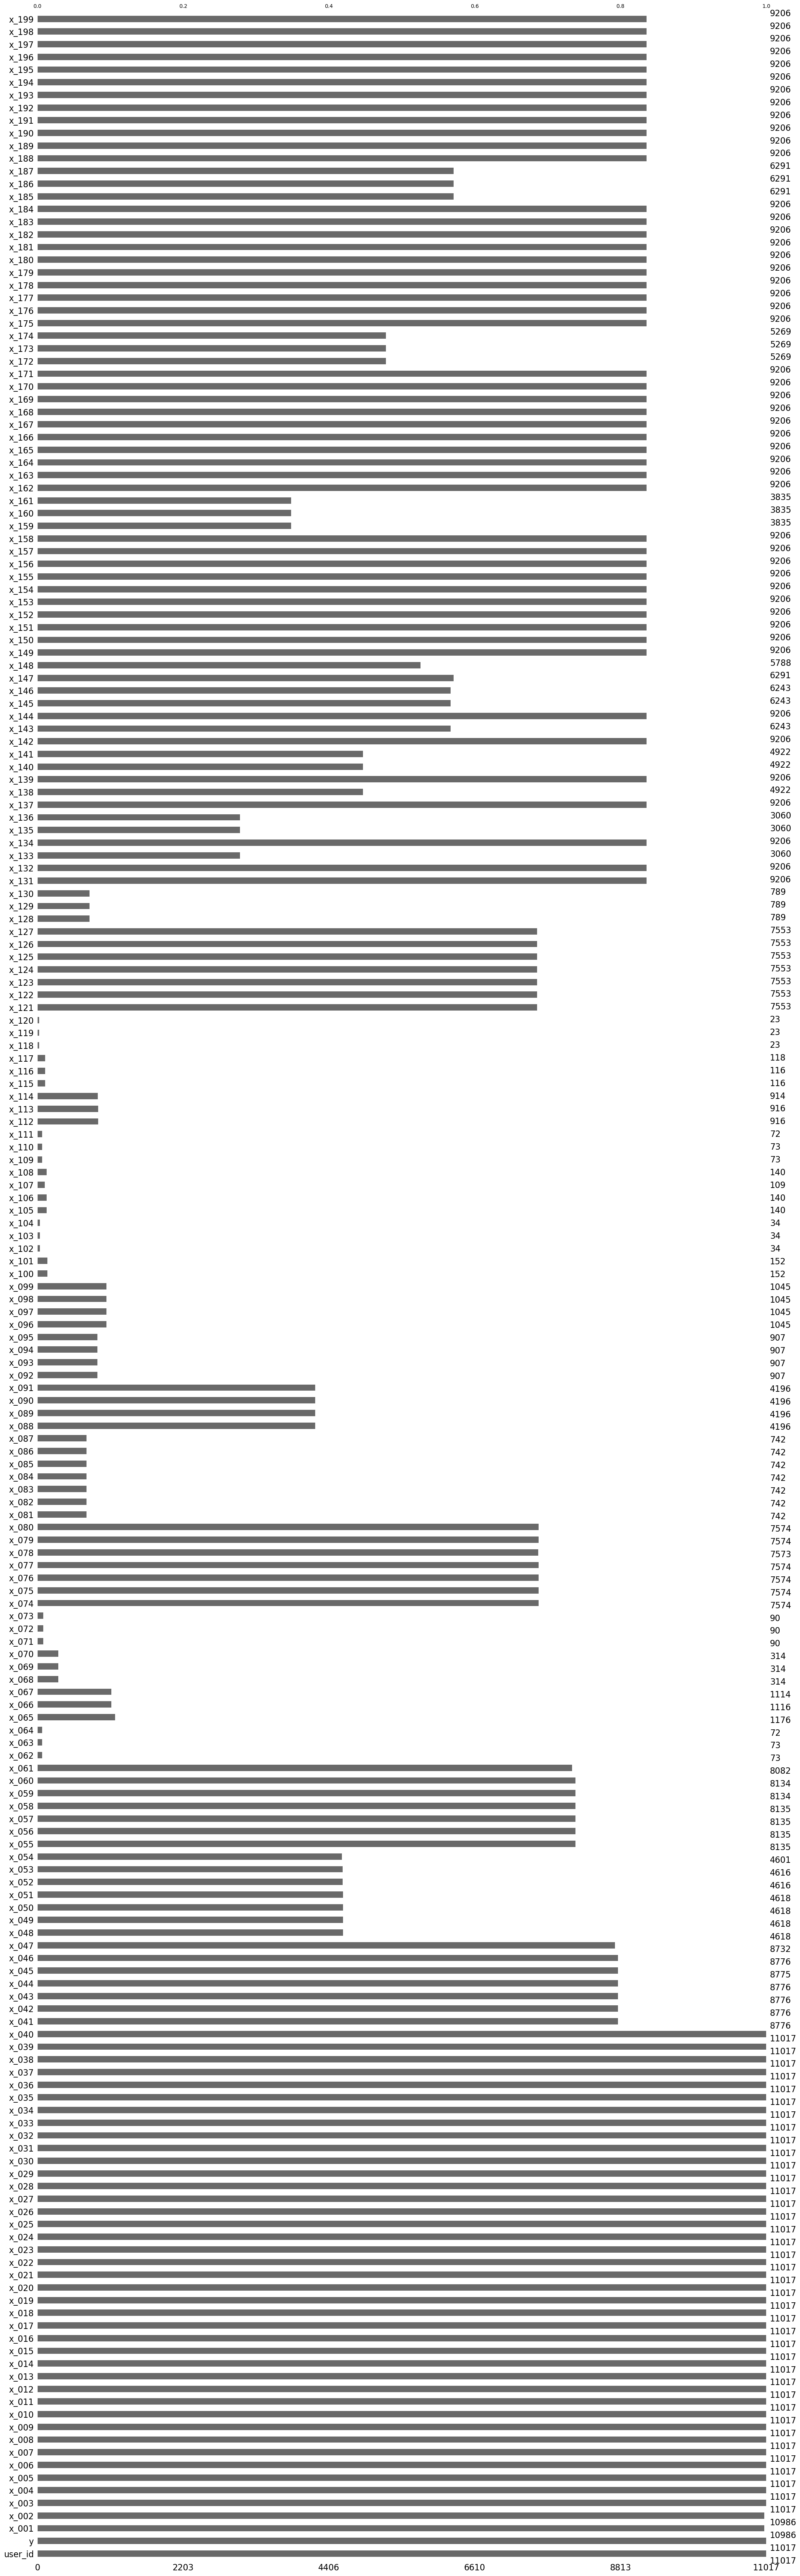

In [4]:
msno.bar(df) 

<Axes: >

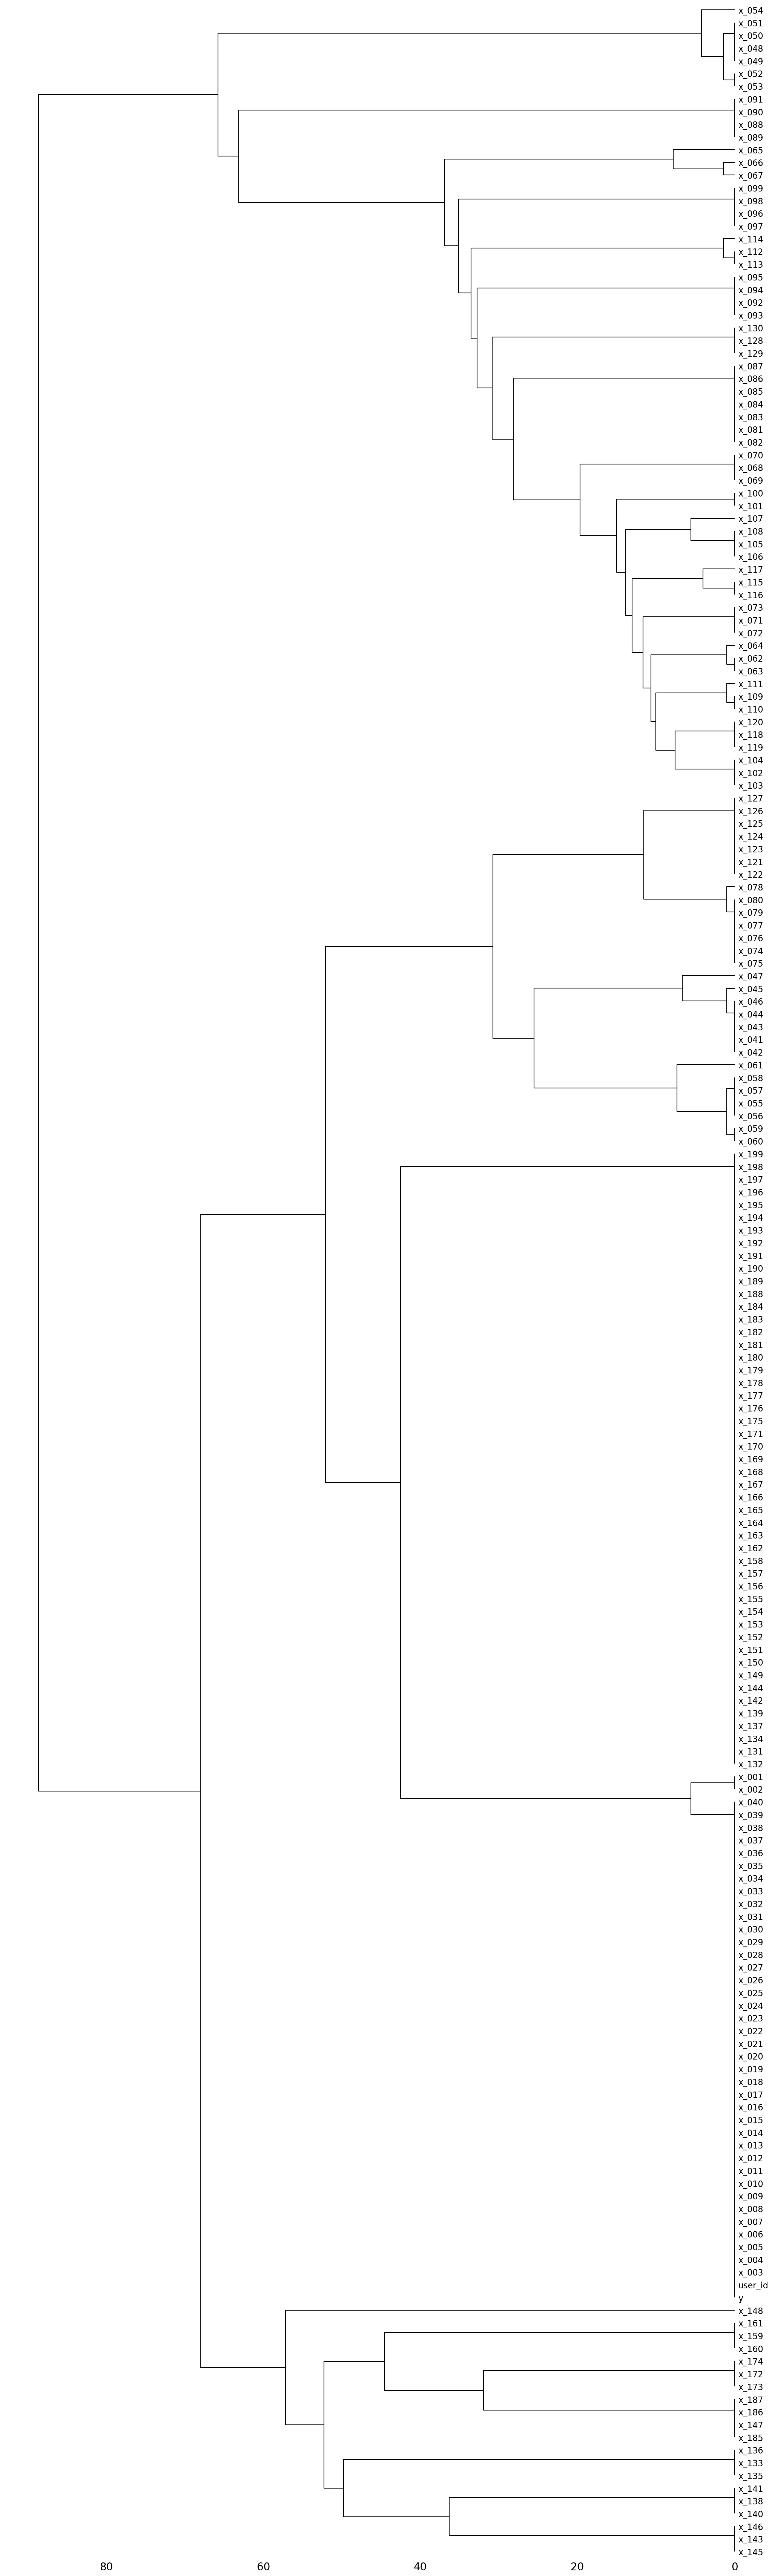

In [5]:
msno.dendrogram(df)

## 缺失值处理
将缺失率大于70%的列删除。再用***随机森林模型***进行填补，最后根据大模型所给建议对特征列进行手动删除。随机森林拟合代码如下：
``` python
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

df=pd.read_csv(r'C:\Users\Nostalgia\Desktop\new_sample_1.csv',index_col=0)

missing_rate = df.isnull().mean()

threshold = 0.7
columns_to_drop = missing_rate[missing_rate > threshold].index
df_filtered = df.drop(columns=columns_to_drop)

print(f"原列数：{len(df.columns)}")
print(f"删除高缺失率列后列数：{len(df_filtered.columns)}")

moderate_missing = missing_rate[(missing_rate >= 0.1) & (missing_rate <= 0.7)]
moderate_missing = moderate_missing.sort_values(ascending=False)

print(f"中等缺失率（10%-70%）的列：\n{moderate_missing}")

for col in moderate_missing.index:
    print(f"\n正在处理列：{col}")
    df_with_value = df_filtered[~df_filtered[col].isnull()]
    df_missing = df_filtered[df_filtered[col].isnull()]

    other_missing_cols = df_with_value.columns[df_with_value.isnull().any()].tolist()
    features = [f for f in df_with_value.columns if f != col and f not in other_missing_cols]

    for f in features:
        if df_with_value[f].dtype == 'object':
            le = LabelEncoder()
            df_with_value[f] = le.fit_transform(df_with_value[f])
            if not df_missing.empty:
                df_missing[f] = df_missing[f].map(lambda x: le.transform([x])[0] if x in le.classes_ else np.nan)
    
    # 确定是分类还是回归问题
    if df_with_value[col].dtype == 'object':
        # 分类问题
        model = RandomForestClassifier(random_state=1)
        # 处理目标变量为分类变量
        le_target = LabelEncoder()
        y_train = le_target.fit_transform(df_with_value[col])
    else:
        # 回归问题
        model = RandomForestRegressor(random_state=1)
        y_train = df_with_value[col]
    
    X_train = df_with_value[features]
    model.fit(X_train, y_train)
    
    if not df_missing.empty:
        X_test = df_missing[features]
        if X_test.isnull().sum().sum() > 0:

            X_test = X_test.fillna(X_test.mean())
        
        predictions = model.predict(X_test)

        if df_with_value[col].dtype == 'object':
            df_filtered.loc[df_filtered[col].isnull(), col] = le_target.inverse_transform(predictions.astype(int))
        else:
            df_filtered.loc[df_filtered[col].isnull(), col] = predictions
    
    print(f"完成填补，{col} 列的当前缺失值数量：{df_filtered[col].isnull().sum()}")

# 保存处理后的数据

    df_filtered.to_csv(r'C:\Users\Nostalgia\Desktop\new_sample_2.csv', index=False)
    print("\n数据已成功保存到指定路径！")

# 输出最终缺失值统计
print("\n最终缺失值统计：")
print(df_filtered.isnull().sum())
```

In [6]:
# 导入处理好的数据
df1 = pd.read_csv('new_sample_3.csv')
df1

,user_id,y,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,...,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
0,A00002,0,0,32,0,0,0,0,0,4,...,2,2,2000,1,1,1,1,2,2,2
1,A00005,0,0,29,0,0,0,0,0,2,...,0,0,685,1,0,0,0,3,3,3
2,A00006,0,0,31,0,0,0,0,0,3,...,5,5,5221,4,2,2,2,6,6,10
3,A00008,0,0,22,0,0,0,0,0,2,...,0,0,3320,2,2,2,3,3,3,7
4,A00009,0,0,31,0,0,0,0,0,4,...,0,0,686,1,0,0,0,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10981,A21934,0,0,29,0,0,0,0,0,2,...,0,0,669,1,0,0,0,3,3,3
10982,A21936,1,0,25,0,0,0,0,0,5,...,33,33,1544,5,1,1,3,4,4,7
10983,A21938,0,0,28,0,0,0,0,0,2,...,0,0,687,1,0,0,0,0,0,0
10984,A21940,0,0,23,0,0,0,0,0,3,...,0,0,2222,3,1,0,1,3,1,7


## 异常值检查与处理

In [7]:
pd.set_option('display.max_columns', None) # 显示所有的列
df1.describe()

,y,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
count,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,1.098600e+04,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,1.098600e+04,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,1.098600e+04,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000,10986.000000
mean,0.195157,0.155653,31.816221,0.148007,0.075369,0.016111,0.023393,0.000364,3.466867,2.865283,1.103313,1.845804,3.645731,2.422993,0.214728,0.033042,0.014746,15.889769,3.708174,11.747952,2.364694e+04,2.547060,1.562898,1757.664573,341.714637,14.308666,3.224832,13.593938,3.069361,17.258420,1.899503e+04,1.879574,1.278627,14.005735,3.146641,16.963499,2.194673e+04,1809.559166,0.408338,0.526943,0.938194,1.586565,8990.042782,3.038504,0.943382,0.908156,2.382760,2.227744,1626.983433,1.511924,1.026397,0.988713,1.418988,4.877936,4.701802,7.550246
std,0.396340,0.362542,6.234252,0.355123,0.263997,0.125910,0.151156,0.019079,1.959128,2.307073,0.639451,0.979480,2.168278,2.359292,0.514908,0.195769,0.127869,28.882805,1.653685,34.409556,8.036699e+04,4.646308,1.167339,8442.652617,2417.720572,28.472667,1.765668,28.180441,1.741960,37.530011,7.325643e+04,3.591596,0.728890,28.278134,1.708656,37.577224,7.895827e+04,5793.575155,0.761392,1.115559,1.335044,1.937207,14217.763086,4.628804,1.067191,2.049420,10.153162,9.778122,6544.198279,1.499110,1.666788,1.611254,3.143690,4.004996,3.860012,8.585752
min,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000e+00,1.000000,1.000000,-3000.000000,-24.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,27.250000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,5.000000,3.000000,1.000000,3.466750e+03,1.000000,1.000000,125.000000,2.000000,4.000000,2.000000,3.000000,2.000000,1.000000,4.040000e+02,1.000000,1.000000,3.000000,2.000000,1.000000,2.704000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,3158.000000,0.000000,0.000000,0.000000,0.000000,0.000000,669.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,3.000000
50%,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,1.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.000000,3.000000,2.000000,6.864000e+03,1.000000,1.000000,125.000000,4.000000,5.000000,3.000000,4.000000,2.000000,2.000000,3.408500e+03,1.000000,1.000000,4.000000,2.000000,2.000000,6.772000e+03,0.000000,0.000000,0.000000,0.000000,1.000000,3241.000000,1.000000,1.000000,0.000000,0.000000,0.000000,690.000000,1.000000,0.000000,0.000000,0.000000,4.000000,3.000000,5.000000
75%,0.000000,0.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,1.000000,3.000000,5.000000,4.000000,0.000000,0.000000,0.000000,18.000000,5.000000,4.000000,2.157000e+04,2.000000,2.000000,702.000000,19.000000,16.000000,5.000000,15.000

发现x_52和x_54有负值，通过查询字段发现这并不符合常识，故认定为异常值，将其所在行删除。

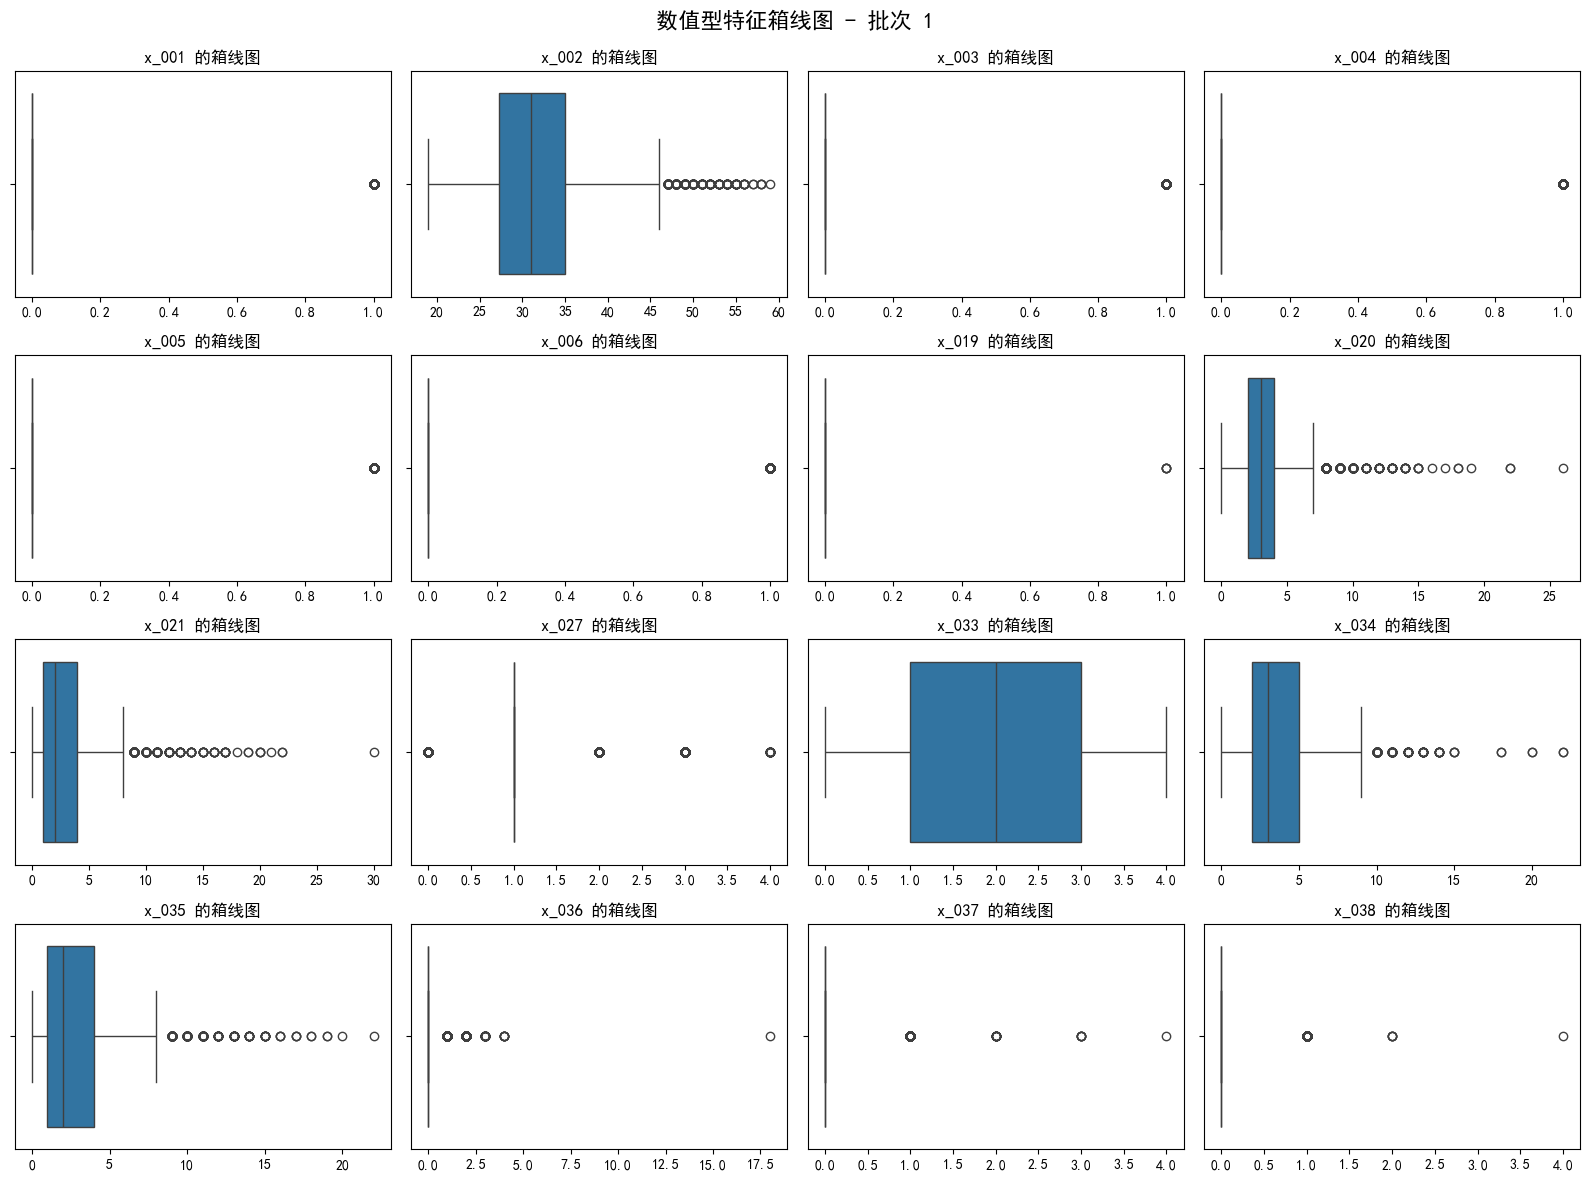

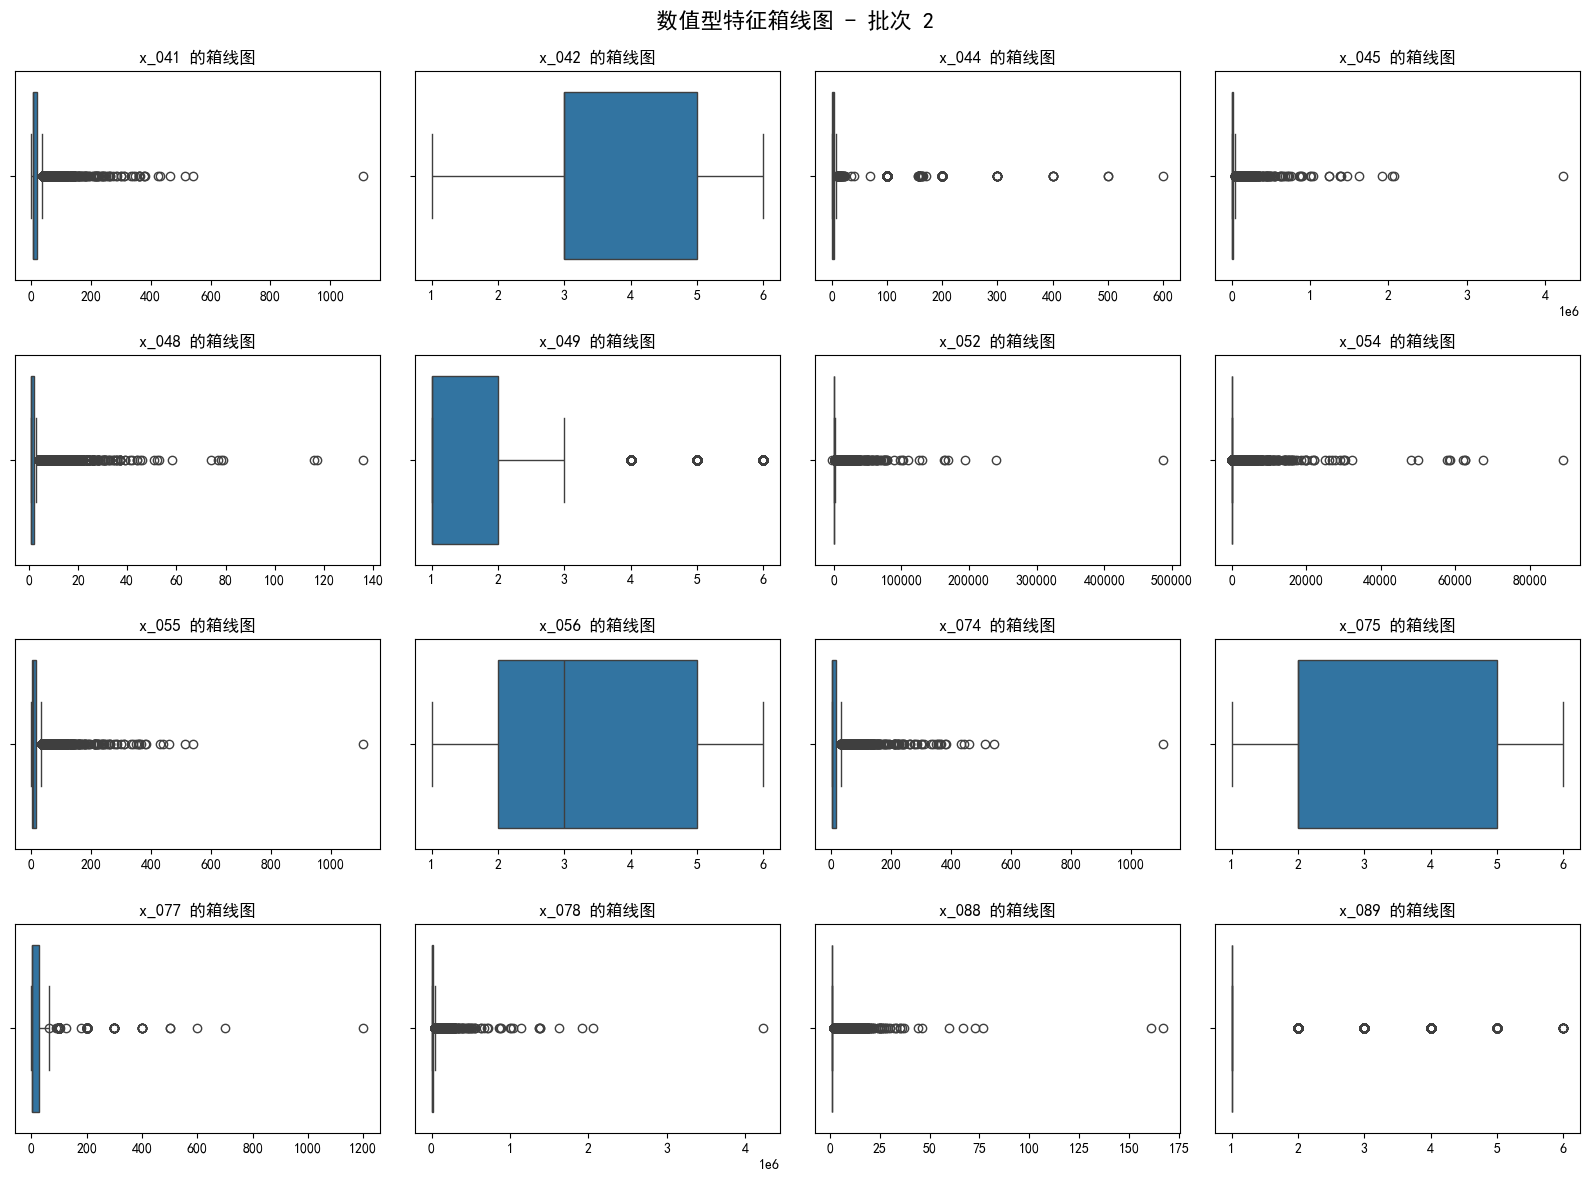

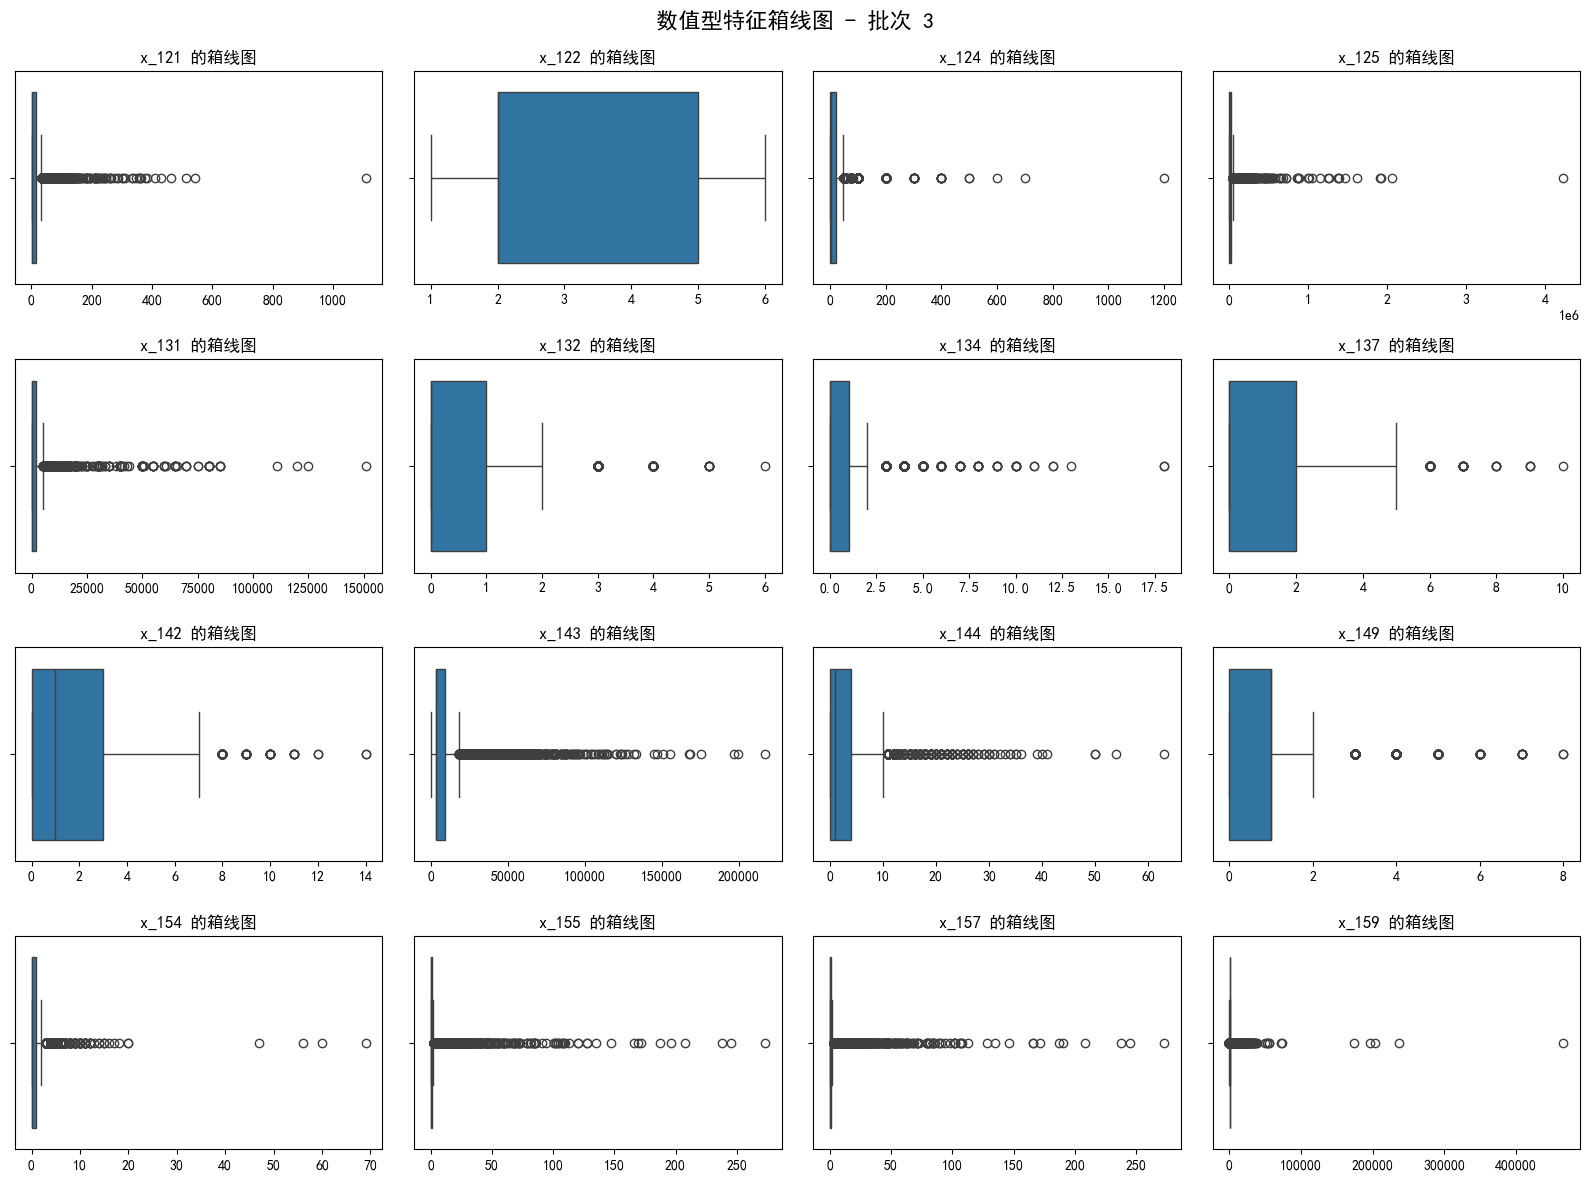

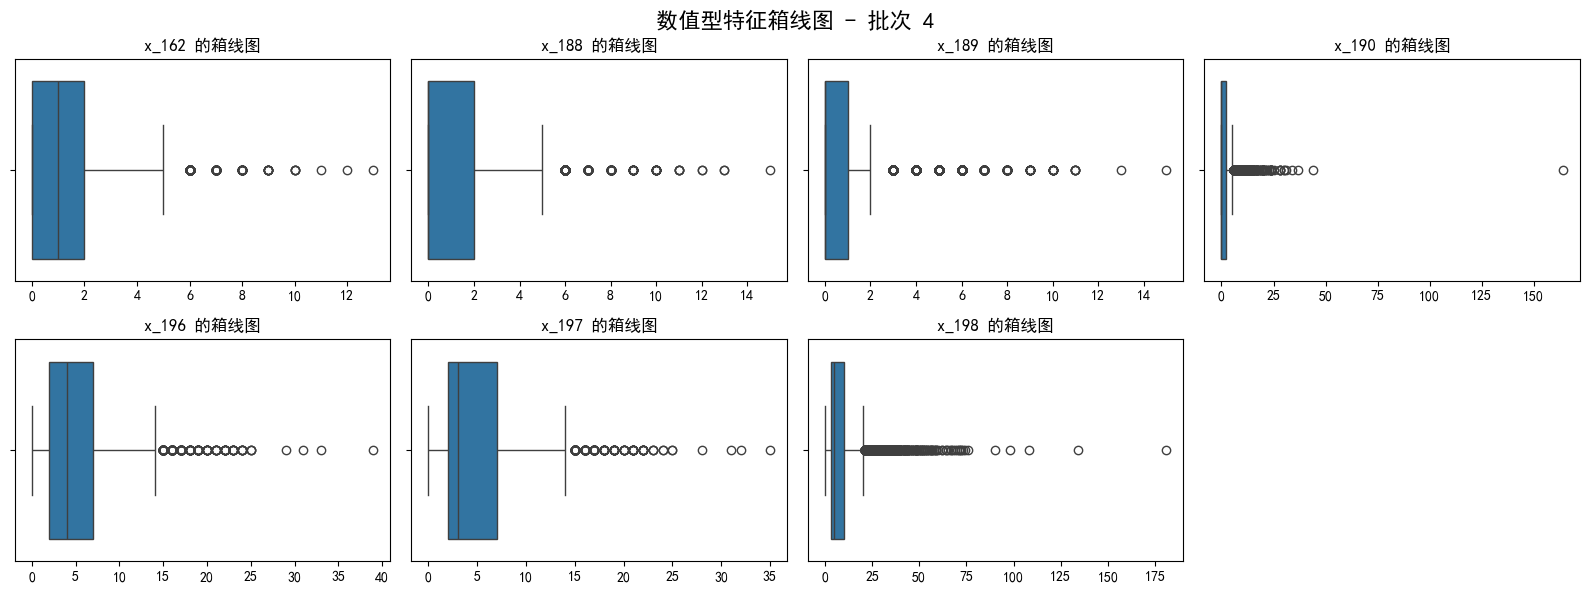

In [8]:
# 中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

def plot_boxplots(data, columns, title, max_cols=4, fig_width=16, fig_height_per_row=3):
    # 动态计算行列数
    n_cols = min(len(columns), max_cols)
    n_rows = (len(columns) + n_cols - 1) // n_cols  # 向上取整
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, n_rows * fig_height_per_row))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]  # 处理单图情况
    
    for i, col in enumerate(columns):
        sns.boxplot(data=data, x=col, ax=axes[i])
        axes[i].set_title(f'{col} 的箱线图')
        axes[i].set_xlabel('')
    
    # 隐藏多余子图
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # 为总标题留出空间
    fig.suptitle(title, fontsize=16)
    plt.show()

# 将数值型列分成多个批次
numeric_columns = df1.columns[2:]  # 排除 user_id 列
batch_size = 16  # 每个批次最多16个特征
batches = [numeric_columns[i:i+batch_size] for i in range(0, len(numeric_columns), batch_size)]

# 为每个批次绘制箱型图
for i, batch in enumerate(batches):
    plot_boxplots(
        data=df1,  # 确保这里传入正确的DataFrame
        columns=batch, 
        title=f'数值型特征箱线图 - 批次 {i+1}',
        max_cols=4,  # 每行最多4个子图
        fig_width=16, 
        fig_height_per_row=3
    )

- 初步观察有较多的异常值
- 通过观察特征列的数据特征，发现很多特征列存在着偏大的异常值，通过大模型我们确定了每个特征标签的异常值字段，如下表所示：
| 变量名 | 异常值下限 | 异常值上限 |
|:------:|:----------:|:----------:|
| y | 0.000 | 0.000 |
| x_001 | 0.000 | 0.000 |
| x_002 | 15.625 | 46.625 |
| x_003 | 0.000 | 0.000 |
| x_004 | 0.000 | 0.000 |
| x_005 | 0.000 | 0.000 |
| x_006 | 0.000 | 0.000 |
| x_019 | 0.000 | 0.000 |
| x_020 | -1.000 | 7.000 |
| x_021 | -3.500 | 8.500 |
| x_027 | 1.000 | 1.000 |
| x_033 | -2.000 | 6.000 |
| x_034 | -2.500 | 9.500 |
| x_035 | -3.500 | 8.500 |
| x_036 | 0.000 | 0.000 |
| x_037 | 0.000 | 0.000 |
| x_038 | 0.000 | 0.000 |
| x_041 | -14.500 | 37.500 |
| x_042 | 0.000 | 8.000 |
| x_044 | -3.500 | 8.500 |
| x_045 | -15195.000 | 43629.000 |
| x_048 | -0.500 | 3.500 |
| x_049 | -0.500 | 3.500 |
| x_052 | -740.500 | 1567.500 |
| x_054 | -18.500 | 41.500 |
| x_055 | -11.500 | 32.500 |
| x_056 | 0.000 | 8.000 |
| x_074 | -12.500 | 31.500 |
| x_075 | -2.500 | 9.500 |
| x_077 | -34.000 | 62.000 |
| x_078 | -18629.875 | 40139.125 |
| x_088 | 1.000 | 1.000 |
| x_089 | 1.000 | 1.000 |
| x_121 | -12.500 | 31.500 |
| x_122 | -2.500 | 9.500 |
| x_124 | -25.000 | 47.000 |
| x_125 | -12425.000 | 38767.000 |
| x_131 | -3000.000 | 5000.000 |
| x_132 | -1.500 | 2.500 |
| x_134 | -1.500 | 2.500 |
| x_137 | -3.000 | 5.000 |
| x_142 | -2.000 | 6.000 |
| x_143 | -5615.000 | 18001.000 |
| x_144 | -3.500 | 8.500 |
| x_149 | 1.000 | 1.000 |
| x_154 | -1.500 | 2.500 |
| x_155 | -1.500 | 2.500 |
| x_157 | -1.500 | 2.500 |
| x_159 | 225.000 | 1465.000 |
| x_162 | -0.500 | 3.500 |
| x_188 | -3.000 | 5.000 |
| x_189 | -1.500 | 2.500 |
| x_190 | -3.000 | 5.000 |
| x_196 | -5.500 | 14.500 |
| x_197 | -5.500 | 14.500 |
| x_198 | -7.500 | 20.500 |

将此区间之外的异常值进行删除，取对数后再次绘制箱线图。

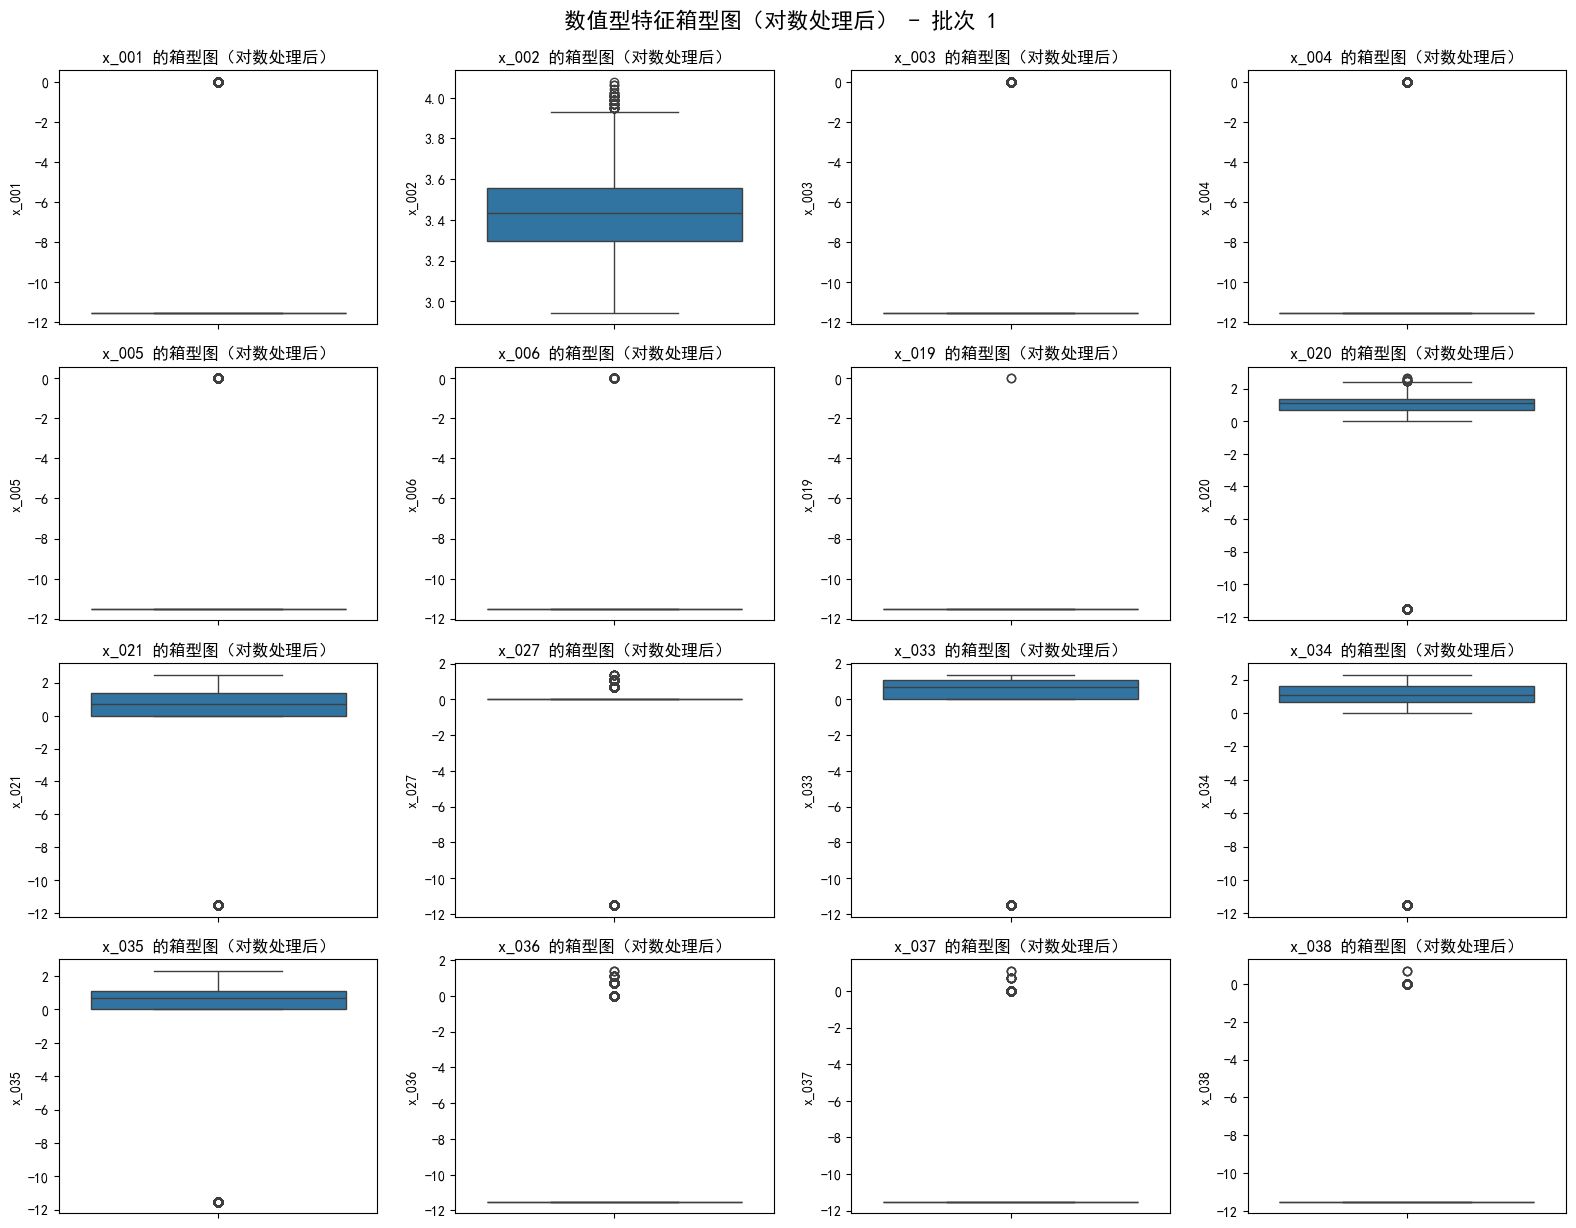

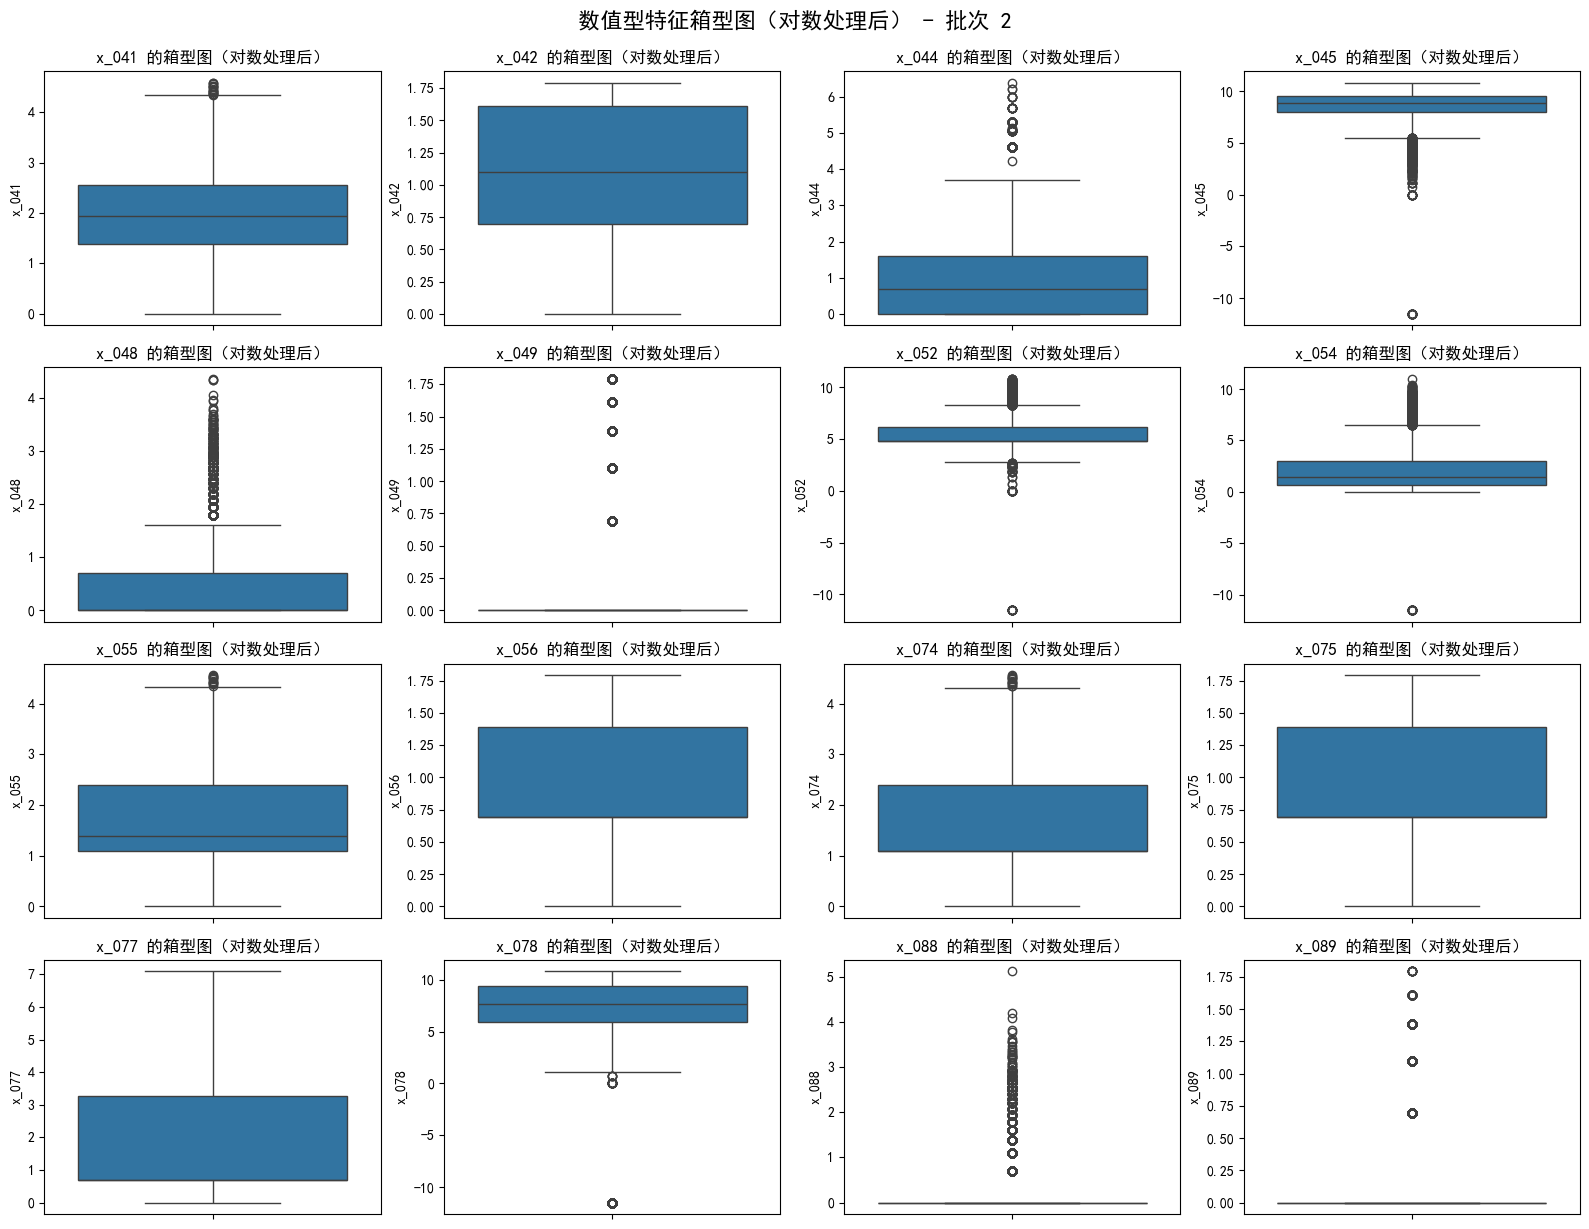

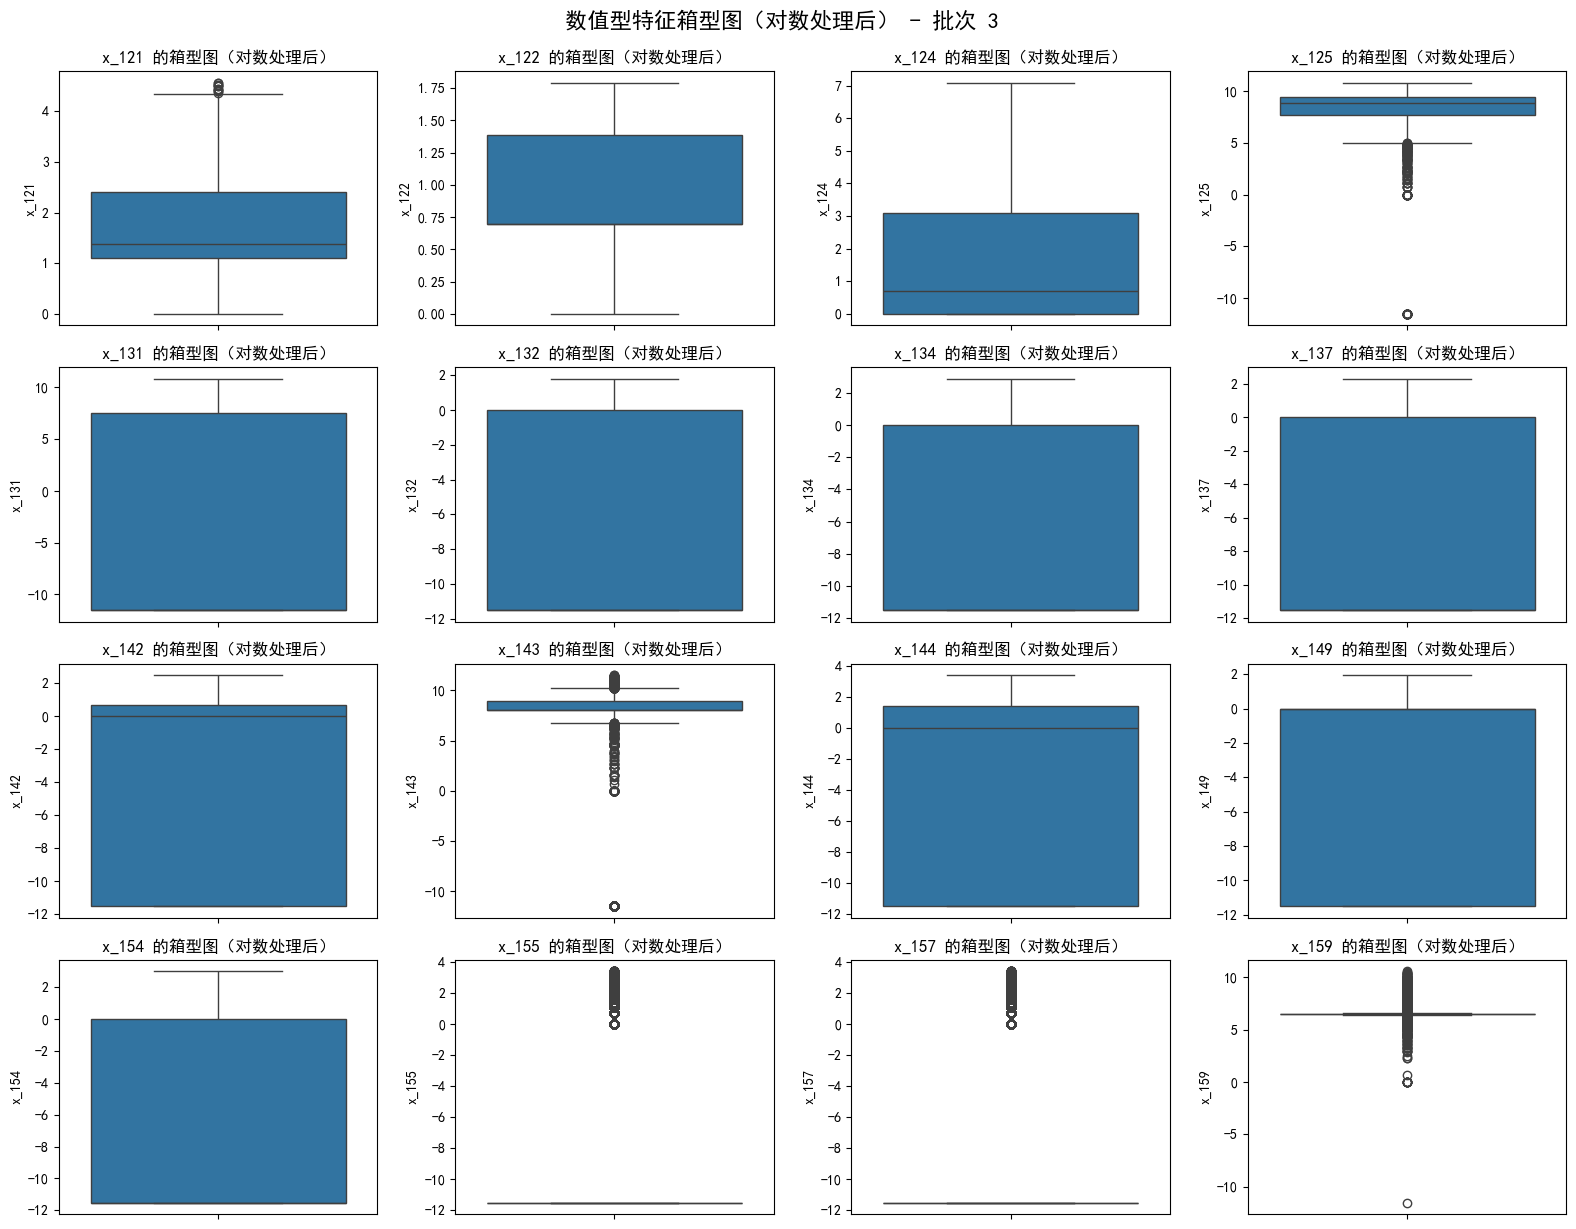

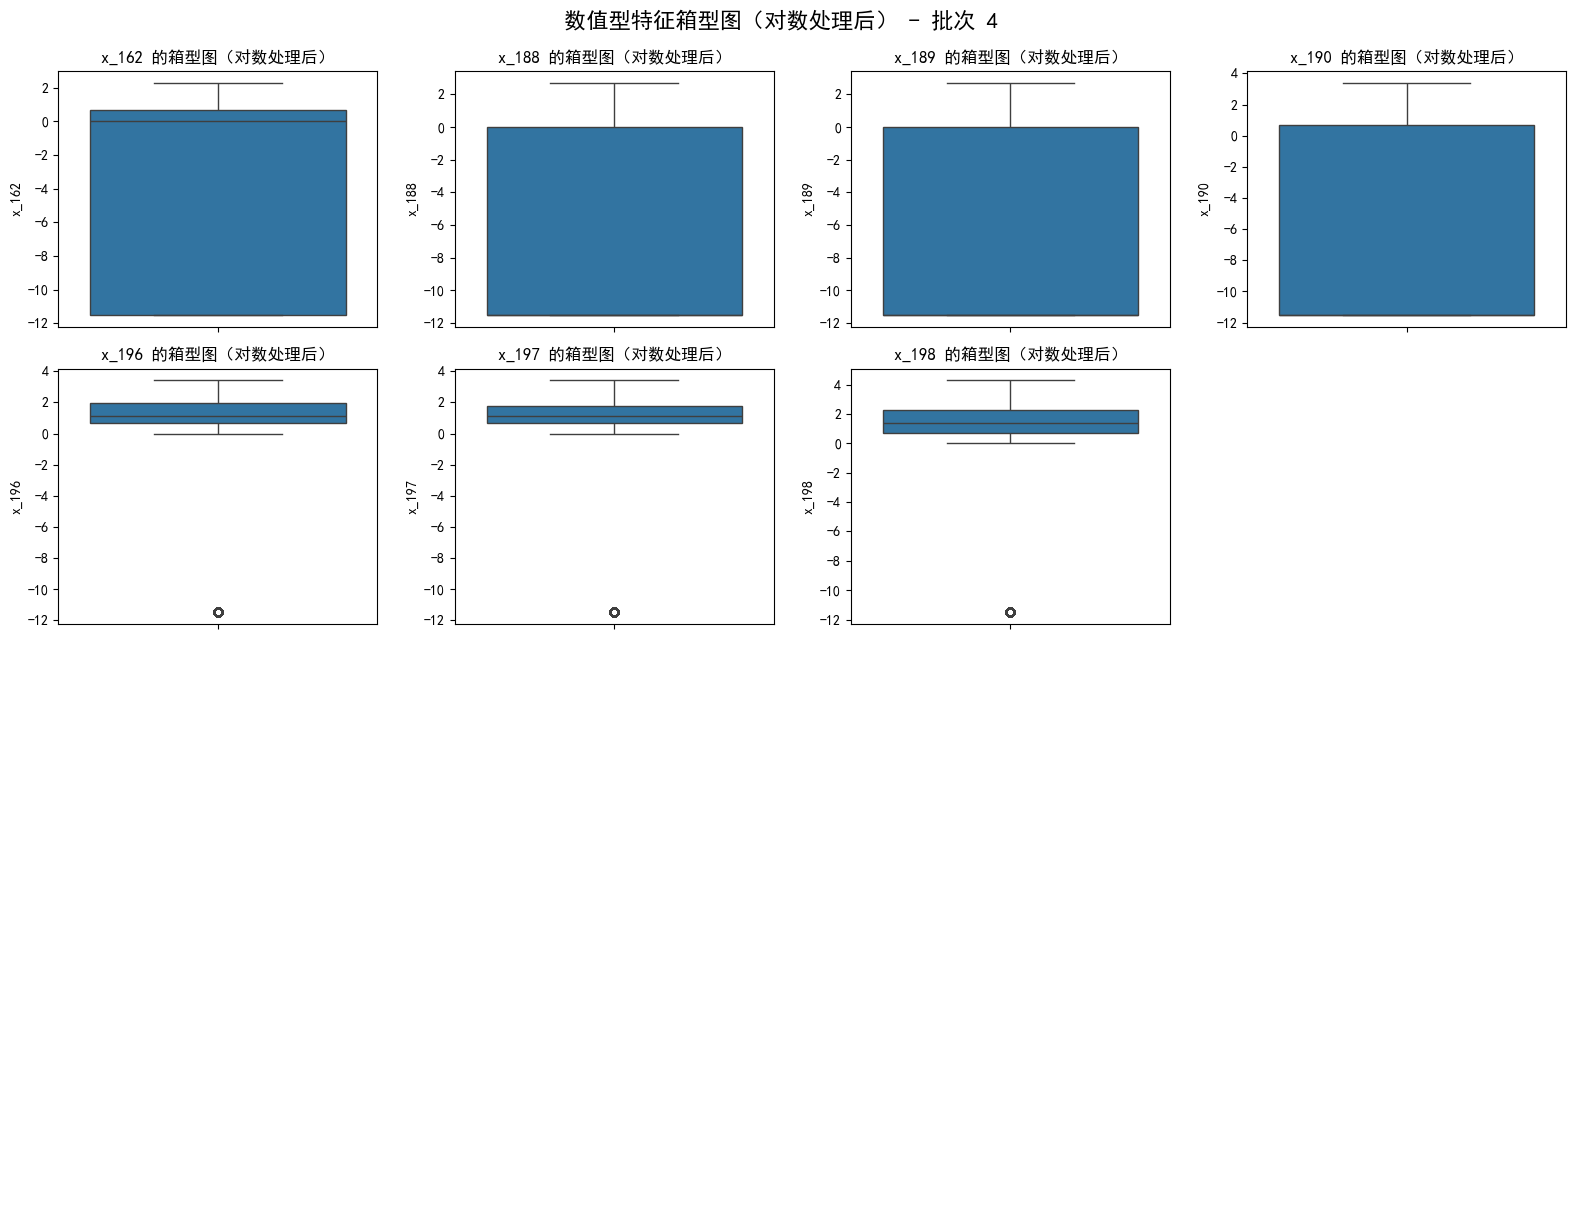

In [9]:
df1 = df1[(df1['x_020']<=15) & (df1['x_021']<=15)]
df1 = df1[(df1['x_034']<=10) & (df1['x_035']<=10) & (df1['x_036']<=10)]
df1 = df1[(df1['x_041']<=100) & (df1['x_045']<=50000) & (df1['x_054'] >= 0)]
df1 = df1[(df1['x_048']<=100) & (df1['x_052']<=50000) & (df1['x_052'] >= 0)]
df1 = df1[(df1['x_055']<=100) & (df1['x_074']<=100) & (df1['x_078']<=50000)]
df1 = df1[(df1['x_121']<=100) & (df1['x_125']<=50000)]
df1 = df1[(df1['x_131']<=50000) & (df1['x_143']<=100000)]
df1 = df1[(df1['x_144']<=30) & (df1['x_154']<=30)]
df1 = df1[(df1['x_155']<=30) & (df1['x_157']<=30)]
df1 = df1[(df1['x_159']<=50000) & (df1['x_190']<=30) & (df1['x_198']<=100)]


def log_transform(data):
    return np.log(data + 0.00001)  

def plot_boxplots(df1, columns, title, nrows=4, ncols=4, figsize=(16, 12), log_process=False):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if i < len(axes):
            # 若开启对数处理，对数据列做转换
            if log_process:
                processed_data = log_transform(df1[col])
            else:
                processed_data = df1[col]
            # 绘制箱型图
            sns.boxplot(data = processed_data, ax = axes[i])
            axes[i].set_title(f'{col} 的箱型图{"（对数处理后）" if log_process else ""}')
            axes[i].set_xlabel('')
    
    # 隐藏空白子图
    for i in range(len(columns), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()
    
numeric_columns = df1.columns[2:]  
batch_size = 16
batches = [numeric_columns[i:i+batch_size] for i in range(0, len(numeric_columns), batch_size)]

# 绘制对数处理后的数据箱型图
for i, batch in enumerate(batches):
    plot_boxplots(df1, batch, f'数值型特征箱型图（对数处理后） - 批次 {i+1}', nrows=4, ncols=4, log_process=True)

通过观察箱型图，发现取对数大大减少了数据的异常情况，由此便为数据集划分和模型的训练奠定了较好的基础

## 数据集划分

In [10]:
x = df1.iloc[:, 2:]
y = df1['y']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
# x_train
y_train

9769     0
8995     0
10170    0
6430     1
10544    0
        ..
6617     1
5993     0
6220     0
1014     0
8397     1
Name: y, Length: 6660, dtype: int64

In [11]:
y_train.value_counts()

y
0    5456
1    1204
Name: count, dtype: int64

In [12]:
y_test.value_counts()

y
0    2334
1     521
Name: count, dtype: int64

由于0和1的数量比例差距太大，我们使用了SMOTETomek过采样方法

## SMOTE+Tomek过采样

In [13]:
# # SMOTE采样
# sm = SMOTE(sampling_strategy = 'minority', random_state=0)
# # 拟合数据集
# x_resample_sm, y_resample_sm = sm.fit_resample(x_train, y_train)

# SMOTE+Tomek混合方法采样
sm = SMOTETomek(random_state=42)
# 拟合数据集
x_resample_sm, y_resample_sm = sm.fit_resample(x_train, y_train)


In [14]:
x_resample_sm

,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
0,0,36,0,0,0,0,0,6,4,2,3,5,5,0,0,0,4,3,2,1685,1,1,300,300,3,2,1,1,1,803,1,1,1,1,1,803,0,0,0,0,0,3239,0,0,0,0,0,693,0,0,0,0,1,1,1
1,0,31,0,0,0,0,0,2,1,0,1,1,1,1,0,0,36,6,2,16175,1,1,125,3,33,6,12,5,2,14248,1,1,12,5,2,14248,3000,0,0,0,1,3000,1,0,0,0,0,685,0,1,1,3,7,7,14
2,0,32,0,0,0,0,0,4,2,1,1,4,1,1,0,0,17,6,3,17672,7,4,978,1,17,6,17,6,3,17672,1,1,17,6,3,17672,3000,0,0,2,4,16675,9,0,0,0,0,548,4,1,1,1,14,13,16
3,0,28,0,0,0,0,0,4,1,1,1,5,0,0,0,0,4,4,100,4497,1,1,34,34,4,4,3,3,100,4464,6,2,3,3,100,4464,300,1,1,2,2,300,2,0,0,0,0,693,0,5,5,5,10,10,12
4,1,35,1,0,0,0,0,4,2,1,1,5,1,0,0,0,18,4,1,25057,1,1,125,3,9,4,9,4,2,17464,1,1,9,4,2,17464,3195,1,1,2,3,11195,4,3,3,2,2,1788,6,0,0,0,7,7,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10581,0,27,0,0,0,0,0,4,2,1,1,2,3,0,0,0,10,6,2,17754,1,1,124,2,10,6,10,6,2,17754,3,2,10,6,2,17754,1827,0,0,1,3,12697,4,1,3,10,8,356,2,2,2,3,8,8,27
10582,0,22,1,0,0,0,0,3,4,0,2,5,1,0,0,0,22,4,2,25869,6,2,480,8,20,4,19,4,1,25608,3,1,19,4,1,25608,0,0,0,1,2,0,3,0,0,0,0,689,0,3,3,4,4,4,7
10583,0,25,0,0,0,0,0,4,2,0,3,4,2,0,0,0,17,5,2,17900,1,1,1386,1376,16,5,16,5,2,17756,5,1,16,5,2,17756,4670,0,0,1,2,4835,2,2,2,0,0,5372,2,1,1,2,7,7,15
10584,0,23,0,0,0,0,0,2,1,1,1,3,0,0,0,0,38,6,2,29120,1,1,122,8,38,6,38,6,2,29120,1,1,38,6,2,29120,1023,1,1,1,1,3474,3,3,3,6,6,4870,3,0,0,0,4,4,7


In [15]:
y_resample_sm.value_counts()

y
0    5293
1    5293
Name: count, dtype: int64

## 数据分箱

In [16]:
# 创建一个新实例用于更改数据
x_train_1 = copy.deepcopy(x_resample_sm)

# 对连续型的列进行分箱,假设箱体为6个
cols = ['x_002', 'x_020', 'x_021', 'x_027', 'x_033', 'x_034', 'x_035', 'x_036', 'x_037', 'x_038', 'x_041', 'x_042', 
            'x_044', 'x_045', 'x_048', 'x_049', 'x_052', 'x_054', 'x_055', 
            'x_056', 'x_074', 'x_075', 'x_077', 'x_078', 'x_088', 'x_089', 
            'x_121', 'x_122', 'x_124', 'x_125', 'x_131', 'x_132', 'x_134', 
            'x_137', 'x_142', 'x_143', 'x_144', 'x_149', 'x_154', 'x_155', 
            'x_157', 'x_159', 'x_162', 'x_188', 'x_189', 'x_190', 'x_196', 'x_197', 'x_198']
for i in cols:
    x_train_1[i]=pd.qcut(x_train_1[i], q=6, duplicates = 'drop')
    
x_train_1

,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
0,0,"(33.0, 36.0]",0,0,0,0,0,"(5.0, 14.0]","(3.0, 4.0]","(1.0, 4.0]","(2.0, 3.0]","(4.0, 5.0]","(4.0, 10.0]","(-0.001, 4.0]","(-0.001, 3.0]","(-0.001, 2.0]","(3.0, 6.0]","(2.0, 3.0]","(0.999, 2.0]","(-0.001, 1958.167]","(0.999, 3.0]","(0.999, 2.0]","(269.0, 1487.0]","(105.0, 58293.0]","(2.0, 4.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(361.0, 992.0]","(0.999, 2.0]","(0.999, 6.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(-0.001, 1514.0]","(-0.001, 135.5]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(3194.0, 3258.0]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(691.0, 797.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 2.0]"
1,0,"(30.0, 33.0]",0,0,0,0,0,"(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 4.0]","(-0.001, 3.0]","(-0.001, 2.0]","(21.0, 98.0]","(5.0, 6.0]","(0.999, 2.0]","(13907.333, 26926.0]","(0.999, 3.0]","(0.999, 2.0]","(122.0, 125.0]","(2.0, 3.0]","(20.0, 96.0]","(5.0, 6.0]","(11.0, 19.0]","(4.0, 5.0]","(0.999, 2.0]","(12187.0, 25105.333]","(0.999, 2.0]","(0.999, 6.0]","(11.0, 19.0]","(4.0, 5.0]","(0.999, 2.0]","(12786.0, 25482.667]","(2850.0, 50000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(2757.5, 3194.0]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(633.0, 685.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(2.0, 3.0]","(6.0, 9.0]","(6.0, 8.0]","(9.0, 14.0]"
2,0,"(30.0, 33.0]",0,0,0,0,0,"(3.0, 4.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(3.0, 4.0]","(-0.001, 1.0]","(-0.001, 4.0]","(-0.001, 3.0]","(-0.001, 2.0]","(12.0, 21.0]","(5.0, 6.0]","(2.0, 3.0]","(13907.333, 26926.0]","(3.0, 79.0]","(2.0, 6.0]","(269.0, 1487.0]","(-0.001, 2.0]","(11.0, 20.0]","(5.0, 6.0]","(11.0, 19.0]","(5.0, 6.0]","(2.0, 4.0]","(12187.0, 25105.333]","(0.999, 2.0]","(0.999, 6.0]","(11.0, 19.0]","(5.0, 6.0]","(2.0, 4.0]","(12786.0, 25482.667]","(2850.0, 50000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 2.0]","(3.0, 12.0]","(14951.333, 99716.0]","(7.0, 29.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(0.999, 633.0]","(3.0, 10.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(9.0, 31.0]","(8.0, 31.0]","(14.0, 68.0]"
3,0,"(26.0, 28.0]",0,0,0,0,0,"(3.0, 4.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(4.0, 5.0]","(-0.001, 1.0]","(-0.001, 4.0]","(-0.001, 3.0]","(-0.001, 2.0]","(3.0, 6.0]","(3.0, 5.0]","(5.0, 600.0]","(1958.167, 6479.0]","(0.999, 3.0]","(0.999, 2.0]","(-0.001, 122.0]","(8.0, 105.0]","(2.0, 4.0]","(3.0, 4.0]","(2.0, 3.0]","(2.0, 3.0]","(29.0, 700.0]","(992.0, 4785.5]","(2.0, 167.0]","(0.999, 6.0]","(2.0, 4.0]","(2.0, 3.0]","(28.0, 700.0]","(1514.0, 5728.0]","(135.5, 1333.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 2.0]","(1.0, 2.0]","(-0.001, 2757.5]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(691.0, 797.0]","(-0.001, 1.0]","(3.0, 15.0]","(2.0, 15.0]","(3.0, 28.0]","(9.0, 31.0]","(8.0, 31.0]","(9.0, 14.0]"
4,1,"(33.0, 36.0]",1,0,0,0,0,"(3.0, 4.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(4.0, 5.0]","(-0.001, 1.0]","(-0.001, 4.0]","(-0.001, 3.0]","(-0.001, 2.0]","(12.0, 21.0]","(3.0, 5.0]","(0.999, 2.0]","(13907.333, 26926.0]","(0.999, 3.0]","(0.999, 2.0]","(122.0, 125.0]","(2.0, 3.0]","(6.0, 11.0]","(3.0, 4.0]","(5.0, 11.0]","(3.0, 4.0]","(0.999, 2.0]","(12187.0, 25105.333]","(0.999, 2.0]","(0.999, 6.0]","(5.0, 11.0]","(3.0, 4.0]","(0.999, 2.0]","(12786.0, 25482.667]","(2850.0, 50000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 2.0]","(2.0, 3.0]","(6500

In [17]:
x_train_1.isnull().count()

x_001    10586
x_002    10586
x_003    10586
x_004    10586
x_005    10586
x_006    10586
x_019    10586
x_020    10586
x_021    10586
x_027    10586
x_033    10586
x_034    10586
x_035    10586
x_036    10586
x_037    10586
x_038    10586
x_041    10586
x_042    10586
x_044    10586
x_045    10586
x_048    10586
x_049    10586
x_052    10586
x_054    10586
x_055    10586
x_056    10586
x_074    10586
x_075    10586
x_077    10586
x_078    10586
x_088    10586
x_089    10586
x_121    10586
x_122    10586
x_124    10586
x_125    10586
x_131    10586
x_132    10586
x_134    10586
x_137    10586
x_142    10586
x_143    10586
x_144    10586
x_149    10586
x_154    10586
x_155    10586
x_157    10586
x_159    10586
x_162    10586
x_188    10586
x_189    10586
x_190    10586
x_196    10586
x_197    10586
x_198    10586
dtype: int64

# 逻辑回归模型

## Model1

分箱后的数据为区间值，不可直接用于训练模型，故先将区间转化为其中点值。

In [18]:
for col in cols:
    x_train_1[col] = x_train_1[col].apply(lambda interval: interval.mid)
    
x_train_1

,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
0,0,34.5000,0,0,0,0,0,9.5000,3.5000,2.5000,2.5000,4.5000,7.0000,1.9995,1.4995,0.9995,4.5000,2.5000,1.4995,979.0830,1.9995,1.4995,878.0000,29199.0000,3.0000,1.4995,1.4995,1.4995,1.4995,676.5000,1.4995,3.4995,1.4995,1.4995,1.4995,756.9995,67.7495,0.4995,0.4995,0.4995,0.4995,3226.0000,0.9995,0.4995,0.4995,0.4995,1.4995,744.0000,0.4995,0.4995,0.4995,0.9995,0.9995,0.4995,0.9995
1,0,31.5000,0,0,0,0,0,0.9995,0.4995,0.4995,0.4995,0.9995,0.4995,1.9995,1.4995,0.9995,59.5000,5.5000,1.4995,20416.6665,1.9995,1.4995,123.5000,2.5000,58.0000,5.5000,15.0000,4.5000,1.4995,18646.1665,1.4995,3.4995,15.0000,4.5000,1.4995,19134.3335,26425.0000,0.4995,0.4995,0.4995,0.4995,2975.7500,0.9995,0.4995,0.4995,0.4995,1.4995,659.0000,0.4995,0.4995,0.4995,2.5000,7.5000,7.0000,11.5000
2,0,31.5000,0,0,0,0,0,3.5000,1.5000,0.4995,0.4995,3.5000,0.4995,1.9995,1.4995,0.9995,16.5000,5.5000,2.5000,20416.6665,41.0000,4.0000,878.0000,0.9995,15.5000,5.5000,15.0000,5.5000,3.0000,18646.1665,1.4995,3.4995,15.0000,5.5000,3.0000,19134.3335,26425.0000,0.4995,0.4995,1.5000,7.5000,57333.6665,18.0000,0.4995,0.4995,0.4995,1.4995,316.9995,6.5000,0.4995,0.4995,0.9995,20.0000,19.5000,41.0000
3,0,27.0000,0,0,0,0,0,3.5000,0.4995,0.4995,0.4995,4.5000,0.4995,1.9995,1.4995,0.9995,4.5000,4.0000,302.5000,4218.5835,1.9995,1.4995,60.9995,56.5000,3.0000,3.5000,2.5000,2.5000,364.5000,2888.7500,84.5000,3.4995,3.0000,2.5000,364.0000,3621.0000,734.2500,0.4995,0.4995,1.5000,1.5000,1378.7495,0.9995,0.4995,0.4995,0.4995,1.4995,744.0000,0.4995,9.0000,8.5000,15.5000,20.0000,19.5000,11.5000
4,1,34.5000,1,0,0,0,0,3.5000,1.5000,0.4995,0.4995,4.5000,0.4995,1.9995,1.4995,0.9995,16.5000,4.0000,1.4995,20416.6665,1.9995,1.4995,123.5000,2.5000,8.5000,3.5000,8.0000,3.5000,1.4995,18646.1665,1.4995,3.4995,8.0000,3.5000,1.4995,19134.3335,26425.0000,0.4995,0.4995,1.5000,2.5000,10725.6665,3.0000,4.5000,8.0000,2.0000,1.4995,1456.8335,6.5000,0.4995,0.4995,0.9995,7.5000,7.0000,7.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10581,0,27.0000,0,0,0,0,0,3.5000,1.5000,0.4995,0.4995,0.9995,3.0000,1.9995,1.4995,0.9995,9.5000,5.5000,1.4995,20416.6665,1.9995,1.4995,123.5000,0.9995,8.5000,5.5000,8.0000,5.5000,1.4995,18646.1665,84.5000,3.4995,8.0000,5.5000,1.4995,19134.3335,2091.5000,0.4995,0.4995,0.4995,2.5000,10725.6665,3.0000,0.4995,8.0000,16.5000,16.5000,316.9995,1.5000,2.0000,1.5000,2.5000,7.5000,7.0000,41.0000
10582,0,22.4995,1,0,0,0,0,2.5000,3.5000,0.4995,1.5000,4.5000,0.4995,1.9995,1.4995,0.9995,59.5000,4.0000,1.4995,20416.6665,41.0000,1.4995,878.0000,6.0000,15.5000,3.5000,15.0000,3.5000,1.4995,37516.1665,84.5000,3.4995,15.0000,3.5000,1.4995,37704.8335,67.7495,0.4995,0.4995,0.4995,1.5000,1378.7495,3.0000,0.4995,0.4995,0.4995,1.4995,688.0000,0.4995,2.0000,8.5000,15.5000,3.5000,3.5000,7.5000
10583,0,22.4995,0,0,0,0,0,3.5000,1.5000,0.4995,2.5000,3.5000,1.5000,1.9995,1.4995,0.9995,16.5000,4.0000,1.4995,20416.6665,1.9995,1.4995,878.0000,29199.0000,15.5000,4.5000,15.0000,4.5000,1.4995,18646.1665,84.5000,3.4995,15.0000,4.5000,1.4995,19134.3335,26425.0000,0.4995,0.4995,0.4995,1.5000,4879.0000,0.9995,1.5000,1.5000,0.4995,1.4995,20716.3335,1.5000,0.4995,0.4995,0.9995,7.5000,7.0000,41.0000
10584,0,22.4995,0,0,0,0,0,0.9995,0.4995,0.4995,0.4995,2.5000,0.4995,1.9995,1.4995,0.9995,59.5000,5.5000,1.4995,38463.0000,1.9995,1.4995,60.9995,6.0000,58.0000,5.5000,57.5000,5.5000,1.4995,37516.1665,1.4995,3.4995,57.5000,5.5000,1.4995,37704.8335,734.2500,0.4995,0.4995,0.4995,0.4995,4879.0000,3.0000,4.5000,8.0000,16.5000,16.5000,20716.3335,2.500

In [19]:
y_train_1 = y_resample_sm

In [20]:
# model_1 = LogisticRegression() 
# model_1.fit(x_train, y_train)

model_1 = LogisticRegression() 
model_1.fit(x_train_1, y_train_1)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Model1评估

```python
# 未过采样未分箱
y_pred_1_1 = model_1.predict(x_train)
y_prob_1_1 = model_1.predict_proba(x_train)[:,1]

print("Accuracy:", model_1.score(x_train, y_train))
print("Precision:", precision_score(y_train, y_pred_1_1))
print("Recall:", recall_score(y_train, y_pred_1_1))
print("F1 Score:", f1_score(y_train, y_pred_1_1))

# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_1, x_train, y_train, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train, y_prob_1_1))
```

```python
# 过采样未分箱
y_pred_1_2 = model_1.predict(x_resample_sm)
y_prob_1_2 = model_1.predict_proba(x_resample_sm)[:,1]

print("Accuracy:", model_1.score(x_resample_sm, y_resample_sm))
print("Precision:", precision_score(y_resample_sm, y_pred_1_2))
print("Recall:", recall_score(y_resample_sm, y_pred_1_2))
print("F1 Score:", f1_score(y_resample_sm, y_pred_1_2))


# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_1, x_resample_sm, y_resample_sm, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_resample_sm, y_prob_1_2))
```

In [21]:
# 过采样且分箱
y_pred_1_3 = model_1.predict(x_train_1)
y_prob_1_3 = model_1.predict_proba(x_train_1)[:,1]
print("Accuracy:", model_1.score(x_train_1, y_train_1))
print("Precision:", precision_score(y_train_1, y_pred_1_3))
print("Recall:", recall_score(y_train_1, y_pred_1_3))
print("F1 Score:", f1_score(y_train_1, y_pred_1_3))


# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_1, x_train_1, y_train_1, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train_1, y_prob_1_3))

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.6849612696013603
Precision: 0.7054133445237096
Recall: 0.6351785376912904
F1 Score: 0.6684561089571528


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

CV （五折交叉验证）: 0.6828853433890761
ROC_AUC_Score: 0.7393277640809672


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 调参（Model2）
- 对Model进行调参得到Model2
- 下用过采样且分箱后的数据训练模型

In [22]:
# 再次训练，以过采样且分箱数据为例
model_2 = LogisticRegression(penalty='l1', solver='liblinear')
model_2.fit(x_train_1, y_train_1)

LogisticRegression(penalty='l1', solver='liblinear')

```python
# 未过采样未分箱
y_pred_2_1 = model_2.predict(x_train)
y_prob_2_1 = model_2.predict_proba(x_train)[:,1]

print("Accuracy:", model_2.score(x_train, y_train))
print("Precision:", precision_score(y_train, y_pred_2_1))
print("Recall:", recall_score(y_train, y_pred_2_1))
print("F1 Score:", f1_score(y_train, y_pred_2_1))

# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_2, x_train, y_train, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train, y_prob_2_1))
```

```python
# 过采样未分箱
y_pred_2_2 = model_2.predict(x_resample_sm)
y_prob_2_2 = model_2.predict_proba(x_resample_sm)[:,1]

print("Accuracy:", model_2.score(x_resample_sm, y_resample_sm))
print("Precision:", precision_score(y_resample_sm, y_pred_2_2))
print("Recall:", recall_score(y_resample_sm, y_pred_2_2))
print("F1 Score:", f1_score(y_resample_sm, y_pred_2_2))


# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_2, x_resample_sm, y_resample_sm, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_resample_sm, y_prob_2_2))
```

In [23]:
# 过采样且分箱
y_pred_2_3 = model_2.predict(x_train_1)
y_prob_2_3 = model_2.predict_proba(x_train_1)[:,1]
print("Accuracy:", model_2.score(x_train_1, y_train_1))
print("Precision:", precision_score(y_train_1, y_pred_2_3))
print("Recall:", recall_score(y_train_1, y_pred_2_3))
print("F1 Score:", f1_score(y_train_1, y_pred_2_3))


# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_2, x_train_1, y_train_1, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train_1, y_prob_2_3))

Accuracy: 0.746363121103344
Precision: 0.7564909520062942
Recall: 0.7266200642357831
F1 Score: 0.7412546978895634
CV （五折交叉验证）: 0.7373044685697819
ROC_AUC_Score: 0.8203675355331905


事实证明，调参之后的逻辑回归模型更优

## Model2在测试集上的表现

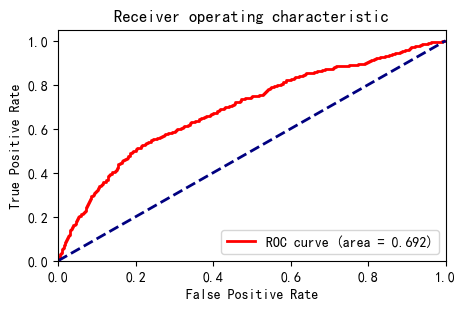

In [24]:
# 注意，这里传入的一定要是 prob 概率值，而不是 pred 预测值！
fpr,tpr,threshold = roc_curve(y_test, model_2.predict_proba(x_test)[:,1])  #计算真正率和假正率
roc_auc = auc(fpr,tpr)     #计算auc的值

plt.figure(figsize=(5,3),dpi=100) # 画布设置
#假正率为横坐标，真正率为纵坐标做曲线
plt.plot(fpr, tpr, color='r',
             lw=2, label='ROC curve (area = %0.3f)' % roc_auc)  
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

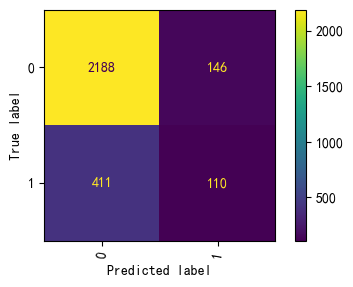

In [25]:
# 绘制混淆矩阵
# 创建画布，可自由更改画布大小
fig, ax = plt.subplots(figsize=(5, 3))
# 创建混淆矩阵
cm = confusion_matrix(y_test, model_2.predict(x_test))
cmp = ConfusionMatrixDisplay(cm, display_labels = model_2.classes_)
cmp.plot(ax = ax)
plt.xticks(rotation=80)
plt.show()

通过绘制ROC曲线，可以发现该模型表现较好

# 决策树模型

## Model3

In [26]:
model_3 = DecisionTreeClassifier() 
model_3.fit((x_train_1), y_train_1)

DecisionTreeClassifier()

## Model3评估

In [27]:
# 过采样且分箱
y_pred_3_3 = model_3.predict(x_train_1)
y_prob_3_3 = model_3.predict_proba(x_train_1)[:,1]
print("Accuracy:", model_3.score(x_train_1, y_train_1))
print("Precision:", precision_score(y_train_1, y_pred_3_3))
print("Recall:", recall_score(y_train_1, y_pred_3_3))
print("F1 Score:", f1_score(y_train_1, y_pred_3_3))


# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_3, x_train_1, y_train_1, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train_1, y_prob_3_3))

Accuracy: 0.9968826752314377
Precision: 0.9988619119878603
Recall: 0.994898923105989
F1 Score: 0.9968764789398958
CV （五折交叉验证）: 0.7699885766690173
ROC_AUC_Score: 0.9999775127285987


决策树模型出现了CV值远低于其他值的情况，怀疑出现了过拟合，这里我们将查看Model3在测试集上的表现

## Model3在测试集上的表现

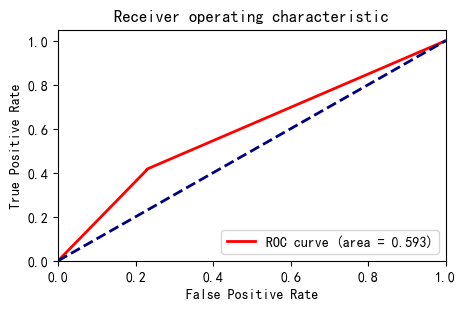

In [28]:
# 注意，这里传入的一定要是 prob 概率值，而不是 pred 预测值！
fpr,tpr,threshold = roc_curve(y_test, model_3.predict_proba(x_test)[:,1])  #计算真正率和假正率
roc_auc = auc(fpr,tpr)     #计算auc的值

plt.figure(figsize=(5,3),dpi=100) # 画布设置
#假正率为横坐标，真正率为纵坐标做曲线
plt.plot(fpr, tpr, color='r',
             lw=2, label='ROC curve (area = %0.3f)' % roc_auc)  
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

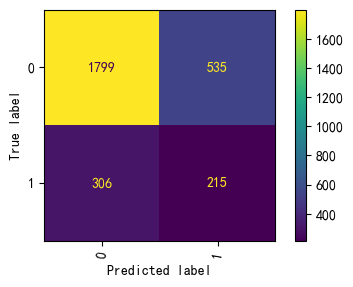

In [29]:
# 绘制混淆矩阵
# 创建画布，可自由更改画布大小
fig, ax = plt.subplots(figsize=(5, 3))
# 创建混淆矩阵
cm = confusion_matrix(y_test, model_3.predict(x_test))
cmp = ConfusionMatrixDisplay(cm, display_labels = model_3.classes_)
cmp.plot(ax = ax)
plt.xticks(rotation=80)
plt.show()

由此可见，该模型并非出现过拟合，但泛化能力不足，故不予采用。

# LightGBM

## Model4✔️

In [30]:
# 创建并训练LightGBM模型
model_4 = lgb.LGBMClassifier(random_state=42)

# 训练模型
model_4.fit(x_train_1, y_train_1)

[LightGBM] [Info] Number of positive: 5293, number of negative: 5293
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 10586, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

## Model4评估

In [31]:
# 过采样且分箱
y_pred_4_3 = model_4.predict(x_train_1)
y_prob_4_3 = model_4.predict_proba(x_train_1)[:,1]
print("Accuracy:", model_4.score(x_train_1, y_train_1))
print("Precision:", precision_score(y_train_1, y_pred_4_3))
print("Recall:", recall_score(y_train_1, y_pred_4_3))
print("F1 Score:", f1_score(y_train_1, y_pred_4_3))

# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_4, x_train_1, y_train_1, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train_1, y_prob_4_3))

Accuracy: 0.9026072170791611
Precision: 0.8880189366351056
Recall: 0.9214056300774608
F1 Score: 0.9044042651831247
[LightGBM] [Info] Number of positive: 4234, number of negative: 4234
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 8468, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 4235, number of negative: 4234
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 

由此可以看出，LightGBM模型在精确度等各方面表现优越，效果极好，接下来查看其在测试集上的表现。

## Model4在测试集上的表现

C:\Users\23893\AppData\Local\Temp\ipykernel_1484\360542042.py:4: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df[col])]


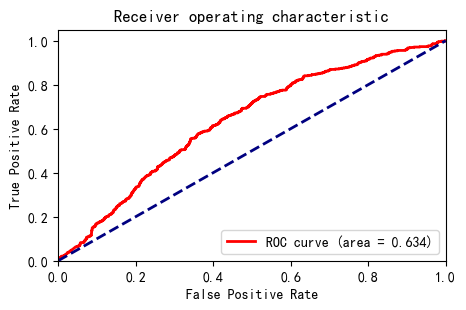

In [32]:
def convert_interval_features(df):
    """将DataFrame中的Interval类型转换为数值特征"""
    interval_cols = [col for col in df.columns 
                    if pd.api.types.is_interval_dtype(df[col])]
    
    for col in interval_cols:
        df[col] = df[col].apply(lambda x: x.mid if pd.notnull(x) else np.nan)
    return df

# 转换数据
x_test_converted = convert_interval_features(x_test)
x_test_processed = x_test_converted.values

# 注意，这里传入的一定要是 prob 概率值，而不是 pred 预测值！
fpr,tpr,threshold = roc_curve(y_test, model_4.predict_proba(x_test_processed)[:,1])  #计算真正率和假正率
roc_auc = auc(fpr,tpr)     #计算auc的值

plt.figure(figsize=(5,3),dpi=100) # 画布设置
#假正率为横坐标，真正率为纵坐标做曲线
plt.plot(fpr, tpr, color='r',
             lw=2, label='ROC curve (area = %0.3f)' % roc_auc)  
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

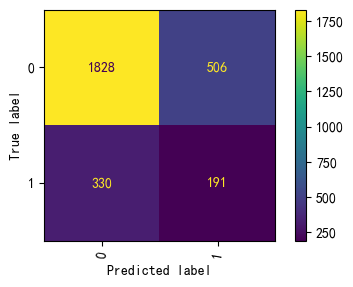

In [33]:
# 绘制混淆矩阵
# 创建画布，可自由更改画布大小
fig, ax = plt.subplots(figsize=(5, 3))
# 创建混淆矩阵
cm = confusion_matrix(y_test, model_4.predict(x_test_processed))
cmp = ConfusionMatrixDisplay(cm, display_labels = model_4.classes_)
cmp.plot(ax = ax)
plt.xticks(rotation=80)
plt.show()

# XGBoost

## Model5

In [34]:
# 转化数据类型
x_train_converted = convert_interval_features(x_train_1)
x_train_processed = x_train_converted.values

# 创建XGBoost分类器
model_5 = xgb.XGBClassifier()
model_5.fit(x_train_processed, y_train_1)

C:\Users\23893\AppData\Local\Temp\ipykernel_1484\360542042.py:4: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df[col])]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Model5评估

In [35]:
# 过采样且分箱
y_pred_5_3 = model_5.predict(x_train_processed)
y_prob_5_3 = model_5.predict_proba(x_train_processed)[:,1]
print("Accuracy:", model_5.score(x_train_processed, y_train_1))
print("Precision:", precision_score(y_train_1, y_pred_5_3))
print("Recall:", recall_score(y_train_1, y_pred_5_3))
print("F1 Score:", f1_score(y_train_1, y_pred_5_3))

# 交叉验证的值
print("CV （五折交叉验证）:",cross_val_score(model_5, x_train_processed, y_train_1, cv=5).mean())
print("ROC_AUC_Score:", roc_auc_score(y_train_1, y_prob_5_3))

Accuracy: 0.980162478745513
Precision: 0.9765610350646915
Recall: 0.9839410542225581
F1 Score: 0.9802371541501976
CV （五折交叉验证）: 0.8425420725160724
ROC_AUC_Score: 0.9979579772863568


## Model5在测试集上的表现

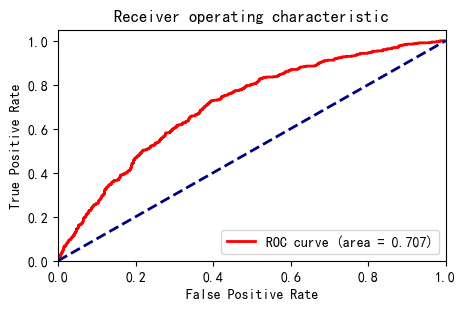

In [36]:
# 注意，这里传入的一定要是 prob 概率值，而不是 pred 预测值！
fpr,tpr,threshold = roc_curve(y_test, model_5.predict_proba(x_test_processed)[:,1])  #计算真正率和假正率
roc_auc = auc(fpr,tpr)     #计算auc的值

plt.figure(figsize=(5,3),dpi=100) # 画布设置
#假正率为横坐标，真正率为纵坐标做曲线
plt.plot(fpr, tpr, color='r',
             lw=2, label='ROC curve (area = %0.3f)' % roc_auc)  
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

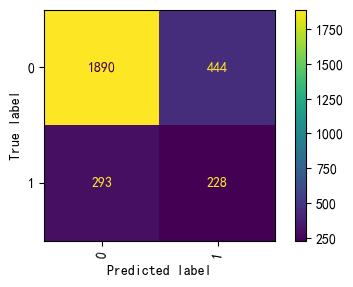

In [37]:
# 绘制混淆矩阵
# 创建画布，可自由更改画布大小
fig, ax = plt.subplots(figsize=(5, 3))
# 创建混淆矩阵
cm = confusion_matrix(y_test, model_5.predict(x_test_processed))
cmp = ConfusionMatrixDisplay(cm, display_labels = model_4.classes_)
cmp.plot(ax = ax)
plt.xticks(rotation=80)
plt.show()

# 评估指标的创新

## 对测试数据进行分箱

In [38]:
# 对测试集数据进行分箱操作（与训练集分箱方式一致）
# 创建一个新实例用于更改数据
x_test_1 = copy.deepcopy(x_test)

# 对连续型的列进行分箱,假设箱体为6个
cols = ['x_002', 'x_020', 'x_021', 'x_027', 'x_033', 'x_034', 'x_035', 'x_036', 'x_037', 'x_038', 'x_041', 'x_042', 
            'x_044', 'x_045', 'x_048', 'x_049', 'x_052', 'x_054', 'x_055', 
            'x_056', 'x_074', 'x_075', 'x_077', 'x_078', 'x_088', 'x_089', 
            'x_121', 'x_122', 'x_124', 'x_125', 'x_131', 'x_132', 'x_134', 
            'x_137', 'x_142', 'x_143', 'x_144', 'x_149', 'x_154', 'x_155', 
            'x_157', 'x_159', 'x_162', 'x_188', 'x_189', 'x_190', 'x_196', 'x_197', 'x_198']
for i in cols:
    x_test_1[i]=pd.qcut(x_test_1[i], q=6, duplicates = 'drop')
    
x_test_1

,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
2840,0,"(18.999, 26.0]",0,1,0,0,0,"(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(2.0, 3.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(-0.001, 1.0]","(10.0, 18.0]","(5.0, 6.0]","(0.999, 2.0]","(9913.333, 21357.333]","(0.999, 3.0]","(0.999, 2.0]","(122.0, 125.0]","(4.0, 6.0]","(8.0, 16.0]","(5.0, 6.0]","(8.0, 16.0]","(5.0, 6.0]","(0.999, 2.0]","(7425.333, 18936.667]","(0.999, 2.0]","(0.999, 5.0]","(8.0, 16.0]","(5.0, 6.0]","(0.999, 2.0]","(8293.0, 19511.667]","(1000.0, 3000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 2.0]","(-0.001, 3137.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 2.0]","(1.0, 30.0]","(684.0, 689.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(5.0, 8.0]","(5.0, 8.0]","(13.0, 74.0]"
1878,0,"(33.0, 37.0]",1,1,0,0,0,"(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 3.0]","(-0.001, 1.0]","(3.0, 6.0]","(2.0, 3.0]","(0.999, 2.0]","(1500.0, 5002.333]","(3.0, 58.0]","(2.0, 6.0]","(1192.667, 48776.0]","(2.0, 3.0]","(4.0, 8.0]","(2.0, 4.0]","(3.0, 8.0]","(0.999, 2.0]","(0.999, 2.0]","(324.0, 500.0]","(0.999, 2.0]","(0.999, 5.0]","(2.0, 4.0]","(2.0, 3.0]","(0.999, 2.0]","(1011.667, 3972.0]","(-0.001, 1000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(3137.0, 3195.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 2.0]","(-0.001, 1.0]","(684.0, 689.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 3.0]","(1.0, 3.0]","(1.0, 3.0]"
7899,0,"(28.0, 31.0]",0,0,0,0,0,"(-0.001, 2.0]","(1.0, 2.0]","(-0.001, 1.0]","(2.0, 3.0]","(-0.001, 2.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 3.0]","(-0.001, 1.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(1500.0, 5002.333]","(0.999, 3.0]","(0.999, 2.0]","(122.0, 125.0]","(3.0, 4.0]","(2.0, 4.0]","(0.999, 2.0]","(2.0, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(2415.0, 7425.333]","(0.999, 2.0]","(0.999, 5.0]","(2.0, 4.0]","(0.999, 2.0]","(0.999, 2.0]","(1011.667, 3972.0]","(-0.001, 1000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 2.0]","(4747.333, 12000.333]","(2.0, 6.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 2.0]","(-0.001, 1.0]","(693.0, 1542.667]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 3.0]"
9547,0,"(31.0, 33.0]",1,0,0,0,0,"(4.0, 5.0]","(3.0, 4.0]","(-0.001, 1.0]","(1.0, 2.0]","(5.0, 10.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 3.0]","(-0.001, 1.0]","(3.0, 6.0]","(3.0, 4.0]","(2.0, 4.0]","(1500.0, 5002.333]","(0.999, 3.0]","(0.999, 2.0]","(133.0, 1192.667]","(99.333, 26210.0]","(2.0, 4.0]","(2.0, 4.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(500.0, 2415.0]","(2.0, 60.0]","(0.999, 5.0]","(0.999, 2.0]","(0.999, 2.0]","(33.0, 1200.0]","(1011.667, 3972.0]","(-0.001, 1000.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(3137.0, 3195.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(-0.001, 2.0]","(-0.001, 1.0]","(632.0, 684.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(1.0, 3.0]","(1.0, 3.0]","(1.0, 3.0]"
3740,0,"(37.0, 55.0]",0,0,0,0,0,"(2.0, 3.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 1.0]","(-0.001, 2.0]","(1.0, 2.0]","(-0.001, 1.0]","(-0.001, 3.0]","(-0.001, 1.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(-0.001, 1500.0]","(0.999, 3.0]","(0.999, 2.0]","(-0.001, 122.0]","(6.0, 99.333]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(2.0, 6.0]","(-0.001, 324.0]","(0.999, 2.0]","(0.999, 5.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(-0.001, 1011.667]","(-0.001, 1000.0]","(-0.001, 1.0]","(-0.001, 1.0]"

In [39]:
for col in cols:
    x_test_1[col] = x_test_1[col].apply(lambda interval: interval.mid)
    
x_test_1

,x_001,x_002,x_003,x_004,x_005,x_006,x_019,x_020,x_021,x_027,x_033,x_034,x_035,x_036,x_037,x_038,x_041,x_042,x_044,x_045,x_048,x_049,x_052,x_054,x_055,x_056,x_074,x_075,x_077,x_078,x_088,x_089,x_121,x_122,x_124,x_125,x_131,x_132,x_134,x_137,x_142,x_143,x_144,x_149,x_154,x_155,x_157,x_159,x_162,x_188,x_189,x_190,x_196,x_197,x_198
2840,0,22.4995,0,1,0,0,0,0.9995,0.4995,0.4995,0.4995,2.5000,0.4995,0.4995,1.4995,0.4995,14.0000,5.5000,1.4995,15635.3330,1.9995,1.4995,123.5000,5.0000,12.0000,5.5000,12.0000,5.5000,1.4995,13181.0000,1.4995,2.9995,12.0000,5.5000,1.4995,13902.3335,2000.0000,0.4995,0.4995,0.4995,1.5000,1568.4995,1.5000,0.4995,0.9995,0.9995,15.5000,686.5000,0.4995,0.4995,0.4995,0.4995,6.5000,6.5000,43.5000
1878,0,35.0000,1,1,0,0,0,0.9995,0.4995,0.4995,0.4995,0.9995,0.4995,0.4995,1.4995,0.4995,4.5000,2.5000,1.4995,3251.1665,30.5000,4.0000,24984.3335,2.5000,6.0000,3.0000,5.5000,1.4995,1.4995,412.0000,1.4995,2.9995,3.0000,2.5000,1.4995,2491.8335,499.9995,0.4995,0.4995,0.4995,0.4995,3166.0000,0.4995,0.4995,0.9995,0.9995,0.4995,686.5000,0.4995,0.4995,0.4995,0.4995,2.0000,2.0000,2.0000
7899,0,29.5000,0,0,0,0,0,0.9995,1.5000,0.4995,2.5000,0.9995,1.5000,0.4995,1.4995,0.4995,1.9995,1.4995,1.4995,3251.1665,1.9995,1.4995,123.5000,3.5000,3.0000,1.4995,2.5000,1.4995,1.4995,4920.1665,1.4995,2.9995,3.0000,1.4995,1.4995,2491.8335,499.9995,0.4995,0.4995,0.4995,1.5000,8373.8330,4.0000,0.4995,0.9995,0.9995,0.4995,1117.8335,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995,2.0000
9547,0,32.0000,1,0,0,0,0,4.5000,3.5000,0.4995,1.5000,7.5000,1.5000,0.4995,1.4995,0.4995,4.5000,3.5000,3.0000,3251.1665,1.9995,1.4995,662.8335,13154.6665,3.0000,3.0000,1.4995,1.4995,1.4995,1457.5000,31.0000,2.9995,1.4995,1.4995,616.5000,2491.8335,499.9995,0.4995,0.4995,0.4995,0.4995,3166.0000,0.4995,0.4995,0.9995,0.9995,0.4995,658.0000,0.4995,0.4995,0.4995,0.4995,2.0000,2.0000,2.0000
3740,0,46.0000,0,0,0,0,0,2.5000,0.4995,0.4995,0.4995,0.9995,1.5000,0.4995,1.4995,0.4995,1.9995,1.4995,1.4995,749.9995,1.9995,1.4995,60.9995,52.6665,1.4995,1.4995,1.4995,1.4995,4.0000,161.9995,1.4995,2.9995,1.4995,1.4995,1.4995,505.8330,499.9995,0.4995,0.4995,0.4995,0.4995,3992.6665,0.4995,0.4995,0.9995,0.9995,0.4995,686.5000,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,0,29.5000,1,0,0,0,0,2.5000,7.5000,0.4995,1.5000,4.5000,3.5000,0.4995,1.4995,0.4995,14.0000,5.5000,1.4995,15635.3330,1.9995,1.4995,123.5000,0.9995,12.0000,5.5000,5.5000,4.0000,1.4995,13181.0000,1.4995,2.9995,6.0000,4.0000,1.4995,13902.3335,499.9995,0.4995,0.4995,0.4995,0.4995,1568.4995,1.5000,0.4995,0.9995,0.9995,0.4995,658.0000,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995
10726,0,35.0000,0,0,1,0,0,8.5000,7.5000,0.4995,2.5000,7.5000,1.5000,0.4995,1.4995,0.4995,14.0000,4.5000,1.4995,15635.3330,30.5000,4.0000,24984.3335,0.9995,6.0000,1.4995,5.5000,1.4995,1.4995,13181.0000,31.0000,2.9995,6.0000,1.4995,1.4995,13902.3335,499.9995,0.4995,0.4995,0.4995,0.4995,3166.0000,0.4995,0.4995,0.9995,0.9995,0.4995,686.5000,0.4995,6.0000,6.0000,16.5000,4.0000,4.0000,3.5000
7345,0,32.0000,0,0,0,0,0,2.5000,1.5000,0.4995,0.4995,0.9995,3.5000,0.4995,1.4995,0.4995,1.9995,1.4995,252.5000,749.9995,1.9995,1.4995,123.5000,2.5000,1.4995,1.4995,1.4995,1.4995,1.4995,161.9995,1.4995,2.9995,1.4995,1.4995,1.4995,505.8330,499.9995,0.4995,0.4995,0.4995,0.4995,3992.6665,0.4995,0.4995,0.9995,0.9995,0.4995,691.0000,0.4995,0.4995,0.4995,0.4995,0.4995,0.4995,2.0000
2579,0,27.0000,0,0,0,0,0,3.5000,1.5000,0.4995,0.4995,4.5000,0.4995,0.4995,1.4995,0.4995,58.0000,5.5000,1.4995,35635.1665,1.9995,1.4995,60.9995,52.6665,52.5000,5.5000,52.5000,5.5000,1.4995,34420.3335,1.4995,2.9995,52.5000,5.5000,1.4995,34707.8335,2000.0000,0.4995,0.4995,1.5000,2.5000,53926.6665,18.0000,4.5000,11.0000,16.0000,15.5000,18971.8335,6.5000,6.0000,6.0000,16.5000,4.0000,4

## KS

In [65]:
# 转化数据类型
x_test_1_converted = convert_interval_features(x_test_1)
x_test_1_processed = x_test_1_converted.values

C:\Users\23893\AppData\Local\Temp\ipykernel_1484\360542042.py:4: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df[col])]


In [66]:
# 定义KS的计算方式
def calculate_ks(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks = np.max(np.abs(tpr - fpr))
    return ks

In [73]:
# 定义模型列表
models = [model_1, model_2, model_3, model_4, model_5]

results_ks = []

for model in models:
    # 1. 训练集预测概率
    y_train_pred_1 = model.predict_proba(x_train_processed)[:, 1]
    
    # 2. 测试集预测概率（需事先准备测试集 x_test）
    y_test_pred_1 = model.predict_proba(x_test_1_processed)[:, 1]
    
    # 3. 计算KS
    ks = calculate_ks(y_train_1, y_train_pred_1)
     
    # 记录结果
    results_ks.append({
        "model": model.__class__.__name__,
        "KS": ks,
    })

# 转为DataFrame分析
results_df_ks = pd.DataFrame(results_ks)
print(results_df_ks)

                    model        KS
0      LogisticRegression  0.386926
1      LogisticRegression  0.494427
2  DecisionTreeClassifier  0.993765
3          LGBMClassifier  0.313244
4           XGBClassifier  0.961459


D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted wi

## PSI

In [58]:
# 定义PSI的计算方式
def calculate_psi_for_binned(train_counts, test_counts):

    # 确保train_counts和test_counts是数组形式
    train_counts = np.array(train_counts)
    test_counts = np.array(test_counts)
    
    # 确保分箱数量一致
    assert len(train_counts) == len(test_counts), "分箱数量不一致"
    
    # 归一化为比例（添加平滑项避免除以零）
    train_total = np.sum(train_counts) + 0.0001
    test_total = np.sum(test_counts) + 0.0001
    
    train_perc = (train_counts / train_total) + 0.0001
    test_perc = (test_counts / test_total) + 0.0001
    
    # 计算PSI
    psi = np.sum((test_perc - train_perc) * np.log(test_perc / train_perc))
    return psi

In [74]:
results_psi = []

for model in models:
    # 1. 训练集预测概率
    y_train_pred_2 = model.predict_proba(x_train_1)[:, 1]
    
    # 2. 测试集预测概率（需事先准备测试集 x_test）
    y_test_pred_2 = model.predict_proba(x_test_1)[:, 1]
    
    # 4. 计算PSI
    psi = calculate_psi(y_train_pred_2, y_test_pred_2)
    
    # 记录结果
    results_psi.append({
        "model": model.__class__.__name__,
        "PSI": psi
    })

# 转为DataFrame分析
results_df_psi = pd.DataFrame(results_psi)
print(results_df_psi)

                    model       PSI
0      LogisticRegression  0.070971
1      LogisticRegression  0.259526
2  DecisionTreeClassifier  0.209923
3          LGBMClassifier  3.380394
4           XGBClassifier  0.045150


# 总结与反思
本节将各模型的评分进行汇总并进行分析。

| 模型               | Accuracy   | Precision  | Recall     | F1 Score   | CV (五折交叉验证) | ROC AUC Score | KS区分度     | PSI值       |
|--------------------|------------|------------|------------|------------|------------------|---------------|-------------|-------------|
| 逻辑回归 (原始)    | 0.68496    | 0.70541    | 0.63518    | 0.66846    | 0.68289          | 0.73933       | 0.386926    | 0.070971    |
| 逻辑回归 (调参后)  | 0.74627    | 0.75644    | 0.72643    | 0.74113    | 0.73693          | 0.82037       | 0.494427    | 0.259526    |
| 决策树             | 0.99688    | 0.99886    | 0.99490    | 0.99688    | 0.77339          | 0.99998       | 0.993765    | 0.209923    |
| LightGBM           | 0.90261    | 0.88802    | 0.92141    | 0.90440    | 0.81826          | 0.96640       | 0.313244    | 3.380394    |
| XGBoost            | 0.98016    | 0.97656    | 0.98394    | 0.98024    | 0.84254          | 0.99796       | 0.961459    | 0.045150    |

- 由此可见，最优模型为XGBoost模型（Model5）。

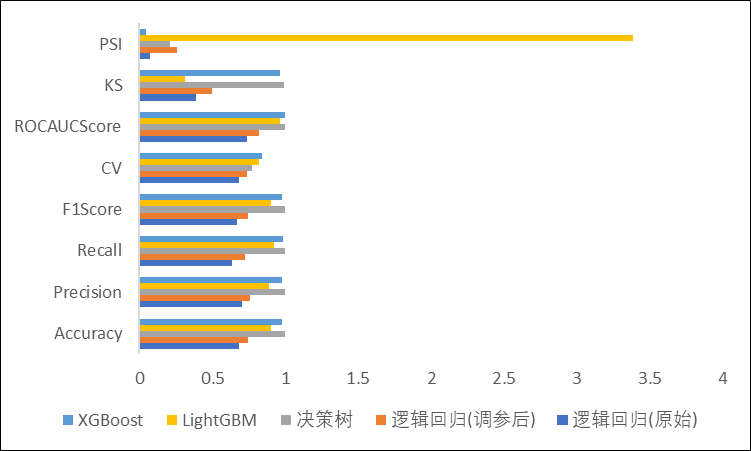